# Density VQE quick test
このノートブックでは `qs.density` モジュールを直接呼び出して、
密度行列ベースの VQE ルーチンが動作することを確認できます。

In [8]:
import math
import numpy as np
from qs import (
    DEFAULT_CONFIG,
    DEFAULT_THETA,
    SimulationConfig,
    compute_expectations,
    single_angle_metrics,
    run_density,
)
import netsquid as ns
# Verify NetSquid formalism and switch to density-matrix if needed
try:
    from netsquid.qubits.qformalism import QFormalism
    print('NetSquid formalism (before):', ns.get_qstate_formalism())
    if ns.get_qstate_formalism() != QFormalism.DM:
        ns.set_qstate_formalism(QFormalism.DM)
        print('Switched to DM formalism:', ns.get_qstate_formalism())
except Exception:
    try:
        print('NetSquid formalism (before):', ns.get_qstate_formalism())
        if hasattr(ns, 'DMForm') and ns.get_qstate_formalism() != ns.DMForm:
            ns.set_qstate_formalism(ns.DMForm)
            print('Switched to DM formalism:', ns.get_qstate_formalism())
    except Exception as e:
        print('Formalism check/set failed:', e)

# 全パラメータを明示的に指定（少しノイジー寄りの設定）
config = SimulationConfig(
    num_runs=DEFAULT_CONFIG.num_runs,
    shots=DEFAULT_CONFIG.shots,
    dephase_rate=0.01,
    client_fidelity=0.01,
    distance=DEFAULT_CONFIG.distance,
    T1=1e7,
    client_T1=1e7,
    T2_ratio=0.05,
    sge=0.005,
    dge=0.02,
    gate_speed_factor=0.8,
    client_gate_speed_factor=0.8,
    entanglement_fidelity=0.85,
    entanglement_speed_factor=100.0,
)

theta = 0.2297
seed = 42
optimize = False
random_theta = False
theta_sweep = None
seed_sweep = None
bounds = (-math.pi, math.pi)
tol = 0.0015


NetSquid formalism (before): <class 'netsquid.qubits.dmtools.DenseDMRepr'>


In [9]:
import itertools
import pandas as pd
from pathlib import Path
from typing import Optional, Sequence

EXCLUDED_DENSITY_KEYS = {'zz_rho', 'xx_rho', 'zz_expectations', 'xx_expectations'}

DEFAULT_SWEEP_GRID = {
    'num_runs_list': [10],
    'shots_list': [10],
    'dephase_rates': [0.01],
    'client_fidelitys': [0.01],
    'distances': [500.0],
    # 'distances': [500,1000,1500,2000,2500,3000,3500,4000,4500,5000],
    'T1s': [1e13],
    'client_T1s': [13],
    'T2_ratios': [0.1],
    'sges': [0.00],
    'dges': [0],
    'gate_speed_factors': [1],
    'client_gate_speed_factors': [1],
    'entanglement_fidelities': [1],
    'entanglement_speed_factors': [100,200,300,400,500,600,700,800,900,1000],
}

EXPORT_DENSITY_SWEEP_DOC = f"""Sweep density-based simulations across the provided parameter lists and export a CSV.

デフォルト設定 (DEFAULT_SWEEP_GRID 参照):
  num_runs_list = {DEFAULT_SWEEP_GRID['num_runs_list']}
  shots_list = {DEFAULT_SWEEP_GRID['shots_list']}
  dephase_rates = {DEFAULT_SWEEP_GRID['dephase_rates']}
  client_fidelitys = {DEFAULT_SWEEP_GRID['client_fidelitys']}
  distances = {DEFAULT_SWEEP_GRID['distances']}
  T1s = {DEFAULT_SWEEP_GRID['T1s']}
  client_T1s = {DEFAULT_SWEEP_GRID['client_T1s']}
  T2_ratios = {DEFAULT_SWEEP_GRID['T2_ratios']}
  sges = {DEFAULT_SWEEP_GRID['sges']}
  dges = {DEFAULT_SWEEP_GRID['dges']}
  gate_speed_factors = {DEFAULT_SWEEP_GRID['gate_speed_factors']}
  client_gate_speed_factors = {DEFAULT_SWEEP_GRID['client_gate_speed_factors']}
  entanglement_fidelities = {DEFAULT_SWEEP_GRID['entanglement_fidelities']}
  entanglement_speed_factors = {DEFAULT_SWEEP_GRID['entanglement_speed_factors']}

The CSV contains total execution time, ZZ/XX execution times, shot count, distance, entanglement speed,
and both gate-speed parameters for every parameter combination.
"""

def export_density_sweep_csv(
    output_path: str = 'data/density_sweep.csv',
    *,
    theta: float = DEFAULT_THETA,
    num_runs_list: Optional[Sequence[int]] = None,
    shots_list: Optional[Sequence[int]] = None,
    dephase_rates: Optional[Sequence[float]] = None,
    client_fidelitys: Optional[Sequence[float]] = None,
    distances: Optional[Sequence[float]] = None,
    T1s: Optional[Sequence[float]] = None,
    client_T1s: Optional[Sequence[float]] = None,
    T2_ratios: Optional[Sequence[float]] = None,
    sges: Optional[Sequence[float]] = None,
    dges: Optional[Sequence[float]] = None,
    gate_speed_factors: Optional[Sequence[float]] = None,
    client_gate_speed_factors: Optional[Sequence[float]] = None,
    entanglement_fidelities: Optional[Sequence[float]] = None,
    entanglement_speed_factors: Optional[Sequence[float]] = None,
    base_seed: int = 42,
    overwrite: bool = True,
) -> pd.DataFrame:
    path = Path(output_path)
    if path.exists() and not overwrite:
        raise FileExistsError(f'{output_path} already exists; set overwrite=True to replace it.')
    path.parent.mkdir(parents=True, exist_ok=True)

    num_runs_list = list(num_runs_list or DEFAULT_SWEEP_GRID['num_runs_list'])
    shots_list = list(shots_list or DEFAULT_SWEEP_GRID['shots_list'])
    dephase_rates = list(dephase_rates or DEFAULT_SWEEP_GRID['dephase_rates'])
    client_fidelitys = list(client_fidelitys or DEFAULT_SWEEP_GRID['client_fidelitys'])
    distances = list(distances or DEFAULT_SWEEP_GRID['distances'])
    T1s = list(T1s or DEFAULT_SWEEP_GRID['T1s'])
    client_T1s = list(client_T1s or DEFAULT_SWEEP_GRID['client_T1s'])
    T2_ratios = list(T2_ratios or DEFAULT_SWEEP_GRID['T2_ratios'])
    sges = list(sges or DEFAULT_SWEEP_GRID['sges'])
    dges = list(dges or DEFAULT_SWEEP_GRID['dges'])
    gate_speed_factors = list(gate_speed_factors or DEFAULT_SWEEP_GRID['gate_speed_factors'])
    client_gate_speed_factors = list(client_gate_speed_factors or DEFAULT_SWEEP_GRID['client_gate_speed_factors'])
    entanglement_fidelities = list(entanglement_fidelities or DEFAULT_SWEEP_GRID['entanglement_fidelities'])
    entanglement_speed_factors = list(entanglement_speed_factors or DEFAULT_SWEEP_GRID['entanglement_speed_factors'])

    records = []
    combos = itertools.product(
        num_runs_list,
        shots_list,
        dephase_rates,
        client_fidelitys,
        distances,
        T1s,
        client_T1s,
        T2_ratios,
        sges,
        dges,
        gate_speed_factors,
        client_gate_speed_factors,
        entanglement_fidelities,
        entanglement_speed_factors,
    )

    for combo in combos:
        (
            num_runs,
            shots,
            dephase_rate,
            client_fidelity,
            distance,
            T1,
            client_T1,
            T2_ratio,
            sge,
            dge,
            gate_speed_factor,
            client_gate_speed_factor,
            entanglement_fidelity,
            entanglement_speed_factor,
        ) = combo

        config = SimulationConfig(
            num_runs=num_runs,
            shots=shots,
            dephase_rate=dephase_rate,
            client_fidelity=client_fidelity,
            distance=distance,
            T1=T1,
            client_T1=client_T1,
            T2_ratio=T2_ratio,
            sge=sge,
            dge=dge,
            gate_speed_factor=gate_speed_factor,
            client_gate_speed_factor=client_gate_speed_factor,
            entanglement_fidelity=entanglement_fidelity,
            entanglement_speed_factor=entanglement_speed_factor,
        )

        energy, metrics = single_angle_metrics(theta, config, base_seed)
        metrics = {k: v for k, v in metrics.items() if k not in EXCLUDED_DENSITY_KEYS}
        metrics.pop('energy', None)

        records.append({
            **metrics,
            'energy': energy,
            'num_runs': num_runs,
            'shots': shots,
            'dephase_rate': dephase_rate,
            'client_fidelity': client_fidelity,
            'distance': distance,
            'T1': T1,
            'client_T1': client_T1,
            'T2_ratio': T2_ratio,
            'sges': sge,
            'dge': dge,
            'gate_speed_factor': gate_speed_factor,
            'client_gate_speed_factor': client_gate_speed_factor,
            'entanglement_fidelity': entanglement_fidelity,
            'entanglement_speed_factor': entanglement_speed_factor,
        })

    df = pd.DataFrame(records)
    df.to_csv(path, index=False)
    return df

export_density_sweep_csv.__doc__ = EXPORT_DENSITY_SWEEP_DOC.strip()


In [10]:
result = run_density(
    theta=theta,
    config=config,
    seed=seed,
    optimize=optimize,
    random_theta=random_theta,
    theta_sweep=theta_sweep,
    seed_sweep=seed_sweep,
    bounds=bounds,
    tol=tol,
)
metrics = result.get('metrics')
expectations = compute_expectations(metrics) if metrics else None
result, expectations


({'mode': 'single',
  'theta': 0.2297,
  'metrics': {'theta': 0.2297,
   'energy': 0.5186469614671667,
   'zz_cost': -0.18692120611938445,
   'xx_cost': 0.0,
   'zz_time': 57506250.0,
   'xx_time': 57675000.0,
   'total_time': 115181250.0,
   'seed': 42,
   'zz_rho': array([[7.76573730e-01+6.47504021e-18j, 3.73830070e-09+3.11697993e-26j,
           0.00000000e+00+0.00000000e+00j, 0.00000000e+00+0.00000000e+00j],
          [3.73830070e-09+3.11697993e-26j, 1.96137286e-01+1.63538473e-18j,
           0.00000000e+00+0.00000000e+00j, 0.00000000e+00+0.00000000e+00j],
          [0.00000000e+00+0.00000000e+00j, 0.00000000e+00+0.00000000e+00j,
           2.17864377e-02+1.81654433e-19j, 1.04876397e-10+8.74455142e-28j],
          [0.00000000e+00+0.00000000e+00j, 0.00000000e+00+0.00000000e+00j,
           1.04876397e-10+8.74455142e-28j, 5.50254613e-03+4.58800061e-20j]]),
   'xx_rho': array([[0.25      +2.08448986e-18j, 0.14843418+1.23763819e-18j,
           0.23517373+1.96086903e-18j, 0.13963128+1.

In [11]:
export_density_sweep_csv()

,theta,zz_cost,xx_cost,zz_time,xx_time,total_time,seed,energy,num_runs,shots,...,distance,T1,client_T1,T2_ratio,sges,dge,gate_speed_factor,client_gate_speed_factor,entanglement_fidelity,entanglement_speed_factor
0,0.2297,-0.4804,1.562484e-14,5.070049e+08,5.071399e+08,1.014145e+09,42,0.225169,10,10,...,500.0,1.000000e+13,13,0.1,0.0,0,1,1,1,100
1,0.2297,-0.4804,3.300660e-15,2.540049e+08,2.541399e+08,5.081448e+08,42,0.225168,10,10,...,500.0,1.000000e+13,13,0.1,0.0,0,1,1,1,200
2,0.2297,-0.4804,2.785405e-15,2.313382e+08,2.314732e+08,4.628115e+08,42,0.225168,10,10,...,500.0,1.000000e+13,13,0.1,0.0,0,1,1,1,300
3,0.2297,-0.4804,2.559603e-15,2.295049e+08,2.296399e+08,4.591448e+08,42,0.225168,10,10,...,500.0,1.000000e+13,13,0.1,0.0,0,1,1,1,400
4,0.2297,-0.4804,3.458520e-15,2.510049e+08,2.511399e+08,5.021448e+08,42,0.225168,10,10,...,500.0,1.000000e+13,13,0.1,0.0,0,1,1,1,500
5,0.2297,-0.4804,2.723272e-15,2.366716e+08,2.368066e+08,4.734782e+08,42,0.225168,10,10,...,500.0,1.000000e+13,13,0.1,0.0,0,1,1,1,600
6,0.2297,-0.4804,3.697961e-15,2.350049e+08,2.351399e+08,4.701448e+08,42,0.225168,10,10,...,500.0,1.000000e+13,13,0.1,0.0,0,1,1,1,700
7,0.2297,-0.4804,2.856884e-15,2.262549e+08,2.263899e+08,4.526448e+08,42,0.225168,10,10,...,500.0,1.000000e+13,13,0.1,0.0,0,1,1,1,800
8,0.2297,-0.4804,3.515097e-15,2.214494e+08,2.295844e+08,4.510337e+08,42,0.225168,10,10,...,500.0,1.000000e+13,13,0.1,0.0,0,1,1,1,900
9,0.2297,-0.4804,3.458014e-15,2.510049e+08,2.511399e+08,5.021448e+08,42,0.225168,10,10,...,500.0,1.000000e+13,13,0.1,0.0,0,1,1,1,1000


Figure saved to: band100-1000_100shot.png


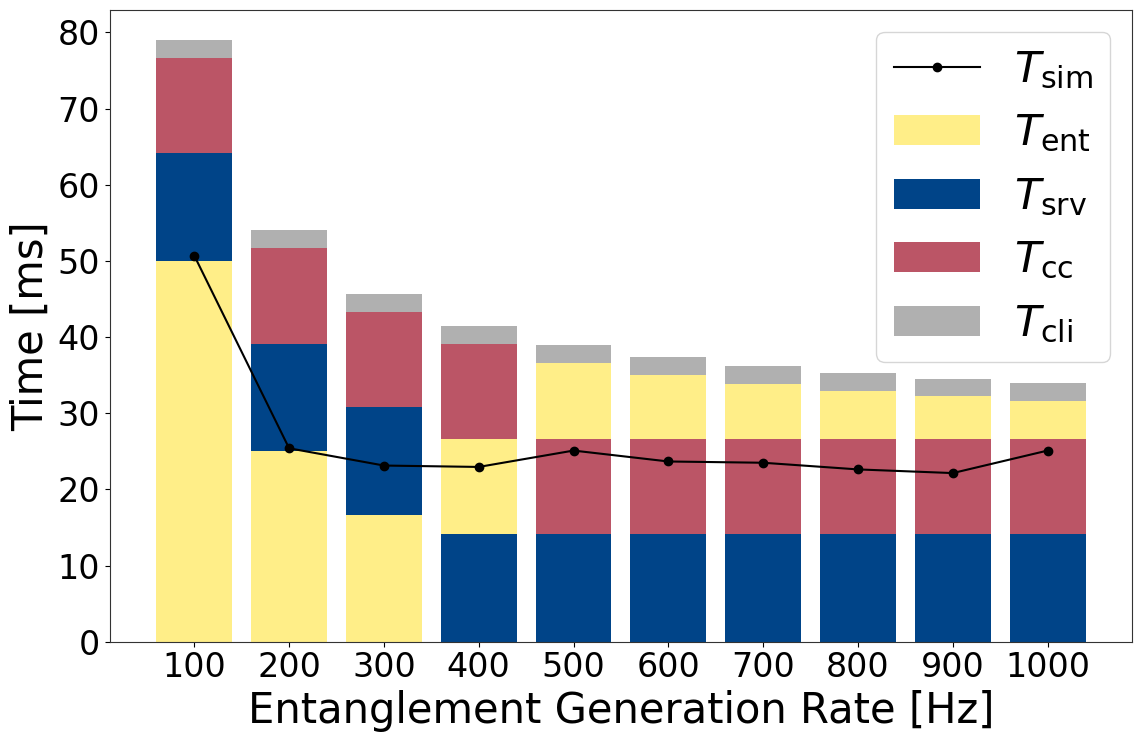

In [12]:
# -*- coding: utf-8 -*-
# Requirements: pandas, matplotlib, numpy
# pip install pandas matplotlib numpy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


plt.rcParams.update({
    "font.size": 26,
    "axes.labelsize": 30,
    "axes.titlesize": 32,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
    "legend.fontsize": 31,
})

# 明るめのルック&フィールに調整（シンプルで明瞭な配色／グリッド無効）
plt.rcParams.update({
    "axes.facecolor": "#FFFFFF",
    "figure.facecolor": "#FFFFFF",
    "axes.edgecolor": "#333333",
    "axes.grid": False,
    "grid.color": "#DDDDDD",
    "grid.alpha": 1.0,
    "grid.linewidth": 1.0,
    "grid.linestyle": "-",
})


# ========= User settings =========
CSV_PATH = "data/density_sweep.csv"           # 解析対象のCSVパス
SWEEP_COL = "entanglement_speed_factor"           # 横軸に使うスイープパラメータの列名
ASSUME_ZZ_TIME_IN_NS = True      # zz_time がナノ秒で与えられている想定
SAVE_FIG = True                 # TrueにするとPNG保存
OUTPUT_FIG_NAME = "band100-1000_100shot.png"
X_AXIS_LABEL = "Entanglement Generation Rate [Hz]"                        # X軸ラベル (None で SWEEP_COL を使用)
# =================================

def choose_unit(max_seconds: float):
    """
    表示の最大値に応じて単位とスケールを自動選択
    戻り値: (scale, unit_label)
    scaleは「秒 × scale = 表示値」
    """
    if max_seconds >= 1:        # 秒
        return 1.0, "s"
    elif max_seconds >= 1e-3:   # ミリ秒
        return 1e3, "ms"
    elif max_seconds >= 1e-6:   # マイクロ秒
        return 1e6, "µs"
    else:                       # ナノ秒
        return 1e9, "ns"

def main():
    # CSV 読み込み
    df = pd.read_csv(CSV_PATH)

    # 入力チェック（必要列の存在確認）
    required_cols = {SWEEP_COL, "distance", "entanglement_speed_factor", "gate_speed_factor", "zz_time", "shots"}
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"CSVに必要な列が不足しています: {missing}")

    # スイープ順に並び替え
    df = df.sort_values(by=SWEEP_COL).reset_index(drop=True)

    # ---- 時間の算出（すべて秒[s]）----
    shots = df["shots"].to_numpy()

    # 1) 5*distance/200000 （1ショットあたり）
    df["t_distance_per_shot_s"] = 5.0 * df["distance"] / 200000.0

    # 2) 5/entanglement_speed_factor（0除算回避, 1ショットあたり）
    if (df["entanglement_speed_factor"] == 0).any():
        raise ZeroDivisionError("entanglement_speed_factor に 0 が含まれています。")
    df["t_entangle_per_shot_s"] = 5.0 / df["entanglement_speed_factor"]

    # 3) 0.0165/gate_speed_factor（0除算回避, 1ショットあたり）
    if (df["gate_speed_factor"] == 0).any():
        raise ZeroDivisionError("gate_speed_factor に 0 が含まれています。")
    df["t_gate_per_shot_s"] = 0.0165 / df["gate_speed_factor"]

    # -- ゲート時間のサーバ/クライアント分解（1ショットあたり）--
    if "gate_time_ns" in df.columns:
        df["t_cli_per_shot_s"] = 15.0 * df["gate_time_ns"].astype(float) * 1e-9
        df["t_srv_per_shot_s"] = df["t_gate_per_shot_s"] - df["t_cli_per_shot_s"]
    else:
        cli_speed = df["client_gate_speed_factor"] if "client_gate_speed_factor" in df.columns else df["gate_speed_factor"]
        df["t_cli_per_shot_s"] = 0.00235 / cli_speed
        df["t_srv_per_shot_s"] = df["t_gate_per_shot_s"] - df["t_cli_per_shot_s"]
    df["t_srv_per_shot_s"] = df["t_srv_per_shot_s"].clip(lower=0)

    # -- ゲート時間のサーバ/クライアント分解（1ショットあたり）--
    if "gate_time_ns" in df.columns:
        df["t_cli_per_shot_s"] = 15.0 * df["gate_time_ns"].astype(float) * 1e-9
        df["t_srv_per_shot_s"] = df["t_gate_per_shot_s"] - df["t_cli_per_shot_s"]
    else:
        cli_speed = df["client_gate_speed_factor"] if "client_gate_speed_factor" in df.columns else df["gate_speed_factor"]
        df["t_cli_per_shot_s"] = 0.00235 / cli_speed
        df["t_srv_per_shot_s"] = df["t_gate_per_shot_s"] - df["t_cli_per_shot_s"]
    df["t_srv_per_shot_s"] = df["t_srv_per_shot_s"].clip(lower=0)

    # -- ゲート時間のサーバ/クライアント分解（1ショットあたり）--
    if "gate_time_ns" in df.columns:
        # absoluteモード: ROT_Z + H + MEASURE を5ラウンド -> 15 * gate_time_ns
        df["t_cli_per_shot_s"] = 15.0 * df["gate_time_ns"].astype(float) * 1e-9
        df["t_srv_per_shot_s"] = df["t_gate_per_shot_s"] - df["t_cli_per_shot_s"]
    else:
        # factorモード: 5 * (ROT_Z + H + MEASURE) = 5 * 0.000470 s = 0.00235 s at factor=1
        cli_speed = df["client_gate_speed_factor"] if "client_gate_speed_factor" in df.columns else df["gate_speed_factor"]
        df["t_cli_per_shot_s"] = 0.00235 / cli_speed
        df["t_srv_per_shot_s"] = df["t_gate_per_shot_s"] - df["t_cli_per_shot_s"]
    df["t_srv_per_shot_s"] = df["t_srv_per_shot_s"].clip(lower=0)

    # 4) zz_time（既に全ショット分の合計が入っている想定）
    if ASSUME_ZZ_TIME_IN_NS:
        df["zz_time_s"] = df["zz_time"] / 1e9
    else:
        df["zz_time_s"] = df["zz_time"] * 1.0

    # ショット数でスケール（まずトータル値を作成）
    df["t_distance_total_s"] = df["t_distance_per_shot_s"] * shots
    df["t_entangle_total_s"] = df["t_entangle_per_shot_s"] * shots
    df["t_gate_total_s"] = df["t_gate_per_shot_s"] * shots
    df["t_cli_total_s"] = df["t_cli_per_shot_s"] * shots
    df["t_srv_total_s"] = df["t_srv_per_shot_s"] * shots
    df["t_cli_total_s"] = df["t_cli_per_shot_s"] * shots
    df["t_srv_total_s"] = df["t_srv_per_shot_s"] * shots
    df["t_cli_total_s"] = df["t_cli_per_shot_s"] * shots
    df["t_srv_total_s"] = df["t_srv_per_shot_s"] * shots

    # ---- 表示単位の自動選択（1ショットあたりに正規化） ----
    stacked_per_shot_s = (df["t_distance_per_shot_s"] + df["t_entangle_per_shot_s"] + df["t_srv_per_shot_s"] + df["t_cli_per_shot_s"]).max()
    max_seconds = max((df["zz_time_s"] / shots).max(), stacked_per_shot_s)
    scale, unit_label = choose_unit(max_seconds)

    # スケーリング
    component_map = {
        "T_ent": (df["t_entangle_total_s"] / shots) * scale,
        "T_cc": (df["t_distance_total_s"] / shots) * scale,
        "Tsrv": (df["t_srv_total_s"] / shots) * scale,
        "Tcli": (df["t_cli_total_s"] / shots) * scale,
    }
    line = (df["zz_time_s"] / shots) * scale
    

    # ---- プロット ----
    x = np.arange(len(df))
    xtick_labels = df[SWEEP_COL].tolist()

    plt.figure(figsize=(12, 8))
    plt.grid(False)
    colors = {
        "Tsrv": "#004488",  # deep navy (darker blue)
        "T_cc": "#BB5566",  # rose (a bit darker red)
        "T_ent": "#FFEE88", # sand (brighter yellow)
        "Tcli": "#B0B0B0",  # lighter gray (client)
    }
    # Legend labels with proper subscripts (upright via \mathrm)
    label_tex = {
        "T_cc": r"$T_{\mathrm{cc}}$",
        "T_ent": r"$T_{\mathrm{ent}}$",
        "Tsrv": r"$T_{\mathrm{srv}}$",
        "Tcli": r"$T_{\mathrm{cli}}$",
    }
    legend_tracker = {label: False for label in component_map}

    for idx, xi in enumerate(x):
        stacked = sorted(
            ((label, values.iat[idx]) for label, values in component_map.items()),
            key=lambda item: item[1],
            reverse=True,
        )
        bottom = 0.0
        for label, value in stacked:
            if value == 0:
                continue
            plt.bar(
                xi,
                value,
                bottom=bottom,
                color=colors[label],
                label=label_tex[label] if not legend_tracker[label] else None,
            )
            bottom += value
            legend_tracker[label] = True

    # 折れ線（zz_time）
    plt.plot(x, line, marker="o", label=r"$T_{\mathrm{sim}}$", color="#000000")


    # 軸・凡例
    plt.xticks(x, xtick_labels, rotation=0)
    plt.tick_params(axis="both", labelsize=24)
    xlabel = SWEEP_COL if X_AXIS_LABEL is None else X_AXIS_LABEL
    plt.xlabel(xlabel)
    plt.ylabel(f"Time [{unit_label}]")
    # plt.title("zz_time (line) vs. stacked times")
    plt.legend()
    plt.tight_layout()

    if SAVE_FIG:
        plt.savefig(OUTPUT_FIG_NAME, dpi=200, bbox_inches="tight")
        print(f"Figure saved to: {OUTPUT_FIG_NAME}")

    plt.show()

if __name__ == "__main__":
    main()


In [13]:
# -*- coding: utf-8 -*-
# Requirements: pandas, matplotlib, numpy
# pip install pandas matplotlib numpy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ========= User settings =========
CSV_PATH = "data/density_sweep.csv"           # 解析対象のCSVパス
SWEEP_COL = "distance"           # 横軸に使うスイープパラメータの列名
ASSUME_ZZ_TIME_IN_NS = True      # zz_time がナノ秒で与えられている想定
SAVE_FIG = False                 # TrueにするとPNG保存
OUTPUT_FIG_NAME = "distance500-5000_100shot.png"
# =================================

def choose_unit(max_seconds: float):
    """
    表示の最大値に応じて単位とスケールを自動選択
    戻り値: (scale, unit_label)
    scaleは「秒 × scale = 表示値」
    """
    if max_seconds >= 1:        # 秒
        return 1.0, "s"
    elif max_seconds >= 1e-3:   # ミリ秒
        return 1e3, "ms"
    elif max_seconds >= 1e-6:   # マイクロ秒
        return 1e6, "µs"
    else:                       # ナノ秒
        return 1e9, "ns"

def main():
    # CSV 読み込み
    df = pd.read_csv(CSV_PATH)

    # 入力チェック（必要列の存在確認）
    required_cols = {SWEEP_COL, "distance", "entanglement_speed_factor", "gate_speed_factor", "zz_time", "shots"}
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"CSVに必要な列が不足しています: {missing}")

    # スイープ順に並び替え
    df = df.sort_values(by=SWEEP_COL).reset_index(drop=True)

    # ---- 時間の算出（すべて秒[s]）----
    shots = df["shots"].to_numpy()

    # 1) 5*distance/200000 （1ショットあたり）
    df["t_distance_per_shot_s"] = 5.0 * df["distance"] / 200000.0

    # 2) 5/entanglement_speed_factor（0除算回避, 1ショットあたり）
    if (df["entanglement_speed_factor"] == 0).any():
        raise ZeroDivisionError("entanglement_speed_factor に 0 が含まれています。")
    df["t_entangle_per_shot_s"] = 5.0 / df["entanglement_speed_factor"]

    # 3) 0.0165/gate_speed_factor（0除算回避, 1ショットあたり）
    if (df["gate_speed_factor"] == 0).any():
        raise ZeroDivisionError("gate_speed_factor に 0 が含まれています。")
    df["t_gate_per_shot_s"] = 0.0165 / df["gate_speed_factor"]

    # 4) zz_time（既に全ショット分の合計が入っている想定）
    if ASSUME_ZZ_TIME_IN_NS:
        df["zz_time_s"] = df["zz_time"] / 1e9
    else:
        df["zz_time_s"] = df["zz_time"] * 1.0

    # ショット数でスケール（積み上げ棒の各成分は全ショット分に拡張）
    df["t_distance_total_s"] = df["t_distance_per_shot_s"] * shots
    df["t_entangle_total_s"] = df["t_entangle_per_shot_s"] * shots
    df["t_gate_total_s"] = df["t_gate_per_shot_s"] * shots

    # ---- 表示単位の自動選択（1ショットあたりに正規化） ----
    stacked_per_shot_s = (df["t_distance_per_shot_s"] + df["t_entangle_per_shot_s"] + df["t_srv_per_shot_s"] + df["t_cli_per_shot_s"]).max()
    max_seconds = max((df["zz_time_s"] / shots).max(), stacked_per_shot_s)
    scale, unit_label = choose_unit(max_seconds)

    # スケーリング
    bar1 = (df["t_distance_total_s"] / shots) * scale
    bar2 = (df["t_entangle_total_s"] / shots) * scale
    bar3 = (df["t_srv_total_s"] / shots) * scale
    bar4 = (df["t_cli_total_s"] / shots) * scale
    line = (df["zz_time_s"] / shots) * scale
    

    # ---- プロット ----
    x = np.arange(len(df))
    xtick_labels = df[SWEEP_COL].tolist()

    plt.figure(figsize=(10, 6))
    plt.grid(False)
    # 積み上げ棒グラフ（シンプルで清潔感のある配色）
    colors = {
        "Tsrv": "#004488",  # deep navy (darker blue)
        "T_cc": "#BB5566",  # rose (a bit darker red)
        "T_ent": "#FFEE88", # sand (brighter yellow)
        "Tcli": "#B0B0B0",  # lighter gray (client)
    }
    plt.bar(x, bar1, label=r"$T_{\mathrm{cc}}$", color=colors["T_cc"])
    plt.bar(x, bar2, bottom=bar1, label=r"$T_{\mathrm{ent}}$", color=colors["T_ent"])
    plt.bar(x, bar3, bottom=(bar1 + bar2), label=r"$T_{\mathrm{srv}}$", color=colors["Tsrv"])
    plt.bar(x, bar4, bottom=(bar1 + bar2 + bar3), label=r"$T_{\mathrm{cli}}$", color=colors["Tcli"])

    # 折れ線（zz_time）
    plt.plot(x, line, marker="o", label=r"$T_{\mathrm{sim}}$", color="#000000")

    # 軸・凡例
    plt.xticks(x, xtick_labels, rotation=0)
    plt.xlabel(SWEEP_COL)
    plt.ylabel(f"Time [{unit_label}]")
    # plt.title("zz_time (line) vs. stacked times")
    plt.legend()
    plt.tight_layout()

    if SAVE_FIG:
        plt.savefig(OUTPUT_FIG_NAME, dpi=200, bbox_inches="tight")
        print(f"Figure saved to: {OUTPUT_FIG_NAME}")

    plt.show()

if __name__ == "__main__":
    main()


KeyError: 't_srv_per_shot_s'

In [14]:
import pandas as pd

# === density_random.csv の比較 ===
CSV_RANDOM_PATH = "data/density_random10*50*100.csv"
df = pd.read_csv(CSV_RANDOM_PATH)

metadata_cols = [c for c in df.columns if c.startswith("experiment_")]
spec_cols = [c for c in df.columns if c.startswith("spec_")]
if metadata_cols or spec_cols:
    if df.empty:
        print("=== experiment metadata ===")
        print("DataFrame is empty; metadata columns exist but no rows are available.")
    else:
        meta_series = df.loc[0, metadata_cols + spec_cols]
        print("=== experiment metadata ===")
        display(meta_series.to_frame(name="value"))

if df.empty:
    print("DataFrame is empty.")
else:
    df["shots"] = df["shots"].astype(float)

    if "zz_time" not in df.columns:
        raise KeyError("CSV に 'zz_time' 列が存在しません。")
    df["zz_time_total_ns"] = df["zz_time"].astype(float)
    df["zz_time_total_s"] = df["zz_time_total_ns"] / 1e9
    df["zz_time_per_shot_s"] = df["zz_time_total_s"] / df["shots"].where(df["shots"] != 0, float("nan"))

    df["t_distance_per_shot_s"] = 5.0 * df["distance"].astype(float) / 200000.0

    if (df["entanglement_speed_factor"].astype(float) == 0).any():
        raise ZeroDivisionError("entanglement_speed_factor に 0 が含まれています。")
    df["t_entangle_per_shot_s"] = 5.0 / df["entanglement_speed_factor"].astype(float)

    if (df["gate_speed_factor"].astype(float) == 0).any():
        raise ZeroDivisionError("gate_speed_factor に 0 が含まれています。")
    df["t_gate_per_shot_s"] = 0.0165 / df["gate_speed_factor"].astype(float)

    per_shot_cols = [
        "t_distance_per_shot_s",
        "t_entangle_per_shot_s",
        "t_gate_per_shot_s",
    ]
    df["L_value_per_shot_s"] = df[per_shot_cols].max(axis=1)
    df["U_value_per_shot_s"] = df[per_shot_cols].sum(axis=1)

    df["L_total_s"] = df["L_value_per_shot_s"] * df["shots"]
    df["U_total_s"] = df["U_value_per_shot_s"] * df["shots"]

    if "set_index" not in df.columns:
        df["set_index"] = 0

    df["within_LU_total"] = (df["L_total_s"] <= df["zz_time_total_s"]) & (
        df["zz_time_total_s"] <= df["U_total_s"]
    )
    all_within = bool(df["within_LU_total"].all())
    within_rate = float(df["within_LU_total"].mean()) if len(df) else float("nan")
    print("=== L_total < zz_time_total < U_total check (seconds) ===")
    print(f"All rows satisfy condition: {all_within} (rate {within_rate:.2%})")
    if not all_within:
        print("Rows violating the inequality:")
        display(
            df.loc[
                ~df["within_LU_total"],
                [
                    "set_index",
                    "sample_index",
                    "shots",
                    "L_value_per_shot_s",
                    "U_value_per_shot_s",
                    "L_total_s",
                    "zz_time_total_s",
                    "U_total_s",
                ],
            ]
        )

    summary_rows = []
    detail_indices = set()

    for set_index, subset in df.groupby("set_index", sort=True):
        if subset.empty:
            continue
        idx_actual = subset["zz_time_total_s"].idxmin()
        idx_L = subset["L_total_s"].idxmin()
        idx_U = subset["U_total_s"].idxmin()

        row_actual = df.loc[idx_actual]
        row_L = df.loc[idx_L]
        row_U = df.loc[idx_U]

        summary_rows.append(
            {
                "set_index": set_index,
                "shots": row_actual["shots"],
                "actual_sample_index": row_actual["sample_index"],
                "actual_zz_time_total_s": row_actual["zz_time_total_s"],
                "L_sample_index": row_L["sample_index"],
                "L_value_per_shot_s": row_L["L_value_per_shot_s"],
                "L_total_s": row_L["L_total_s"],
                "L_zz_time_total_s": row_L["zz_time_total_s"],
                "L_abs_regret_s": abs(row_L["zz_time_total_s"] - row_actual["zz_time_total_s"]),
                "L_distance": row_L["distance"],
                "L_entanglement_speed_factor": row_L["entanglement_speed_factor"],
                "L_gate_speed_factor": row_L["gate_speed_factor"],
                "L_client_gate_speed_factor": row_L["client_gate_speed_factor"],
                "U_sample_index": row_U["sample_index"],
                "U_value_per_shot_s": row_U["U_value_per_shot_s"],
                "U_total_s": row_U["U_total_s"],
                "U_zz_time_total_s": row_U["zz_time_total_s"],
                "U_abs_regret_s": abs(row_U["zz_time_total_s"] - row_actual["zz_time_total_s"]),
                "U_distance": row_U["distance"],
                "U_entanglement_speed_factor": row_U["entanglement_speed_factor"],
                "U_gate_speed_factor": row_U["gate_speed_factor"],
                "U_client_gate_speed_factor": row_U["client_gate_speed_factor"],
            }
        )

        detail_indices.update([idx_actual, idx_L, idx_U])

    summary_df = pd.DataFrame(summary_rows)

    if not summary_df.empty:
        L_hits = (summary_df["L_sample_index"] == summary_df["actual_sample_index"]).mean()
        U_hits = (summary_df["U_sample_index"] == summary_df["actual_sample_index"]).mean()

        L_abs = summary_df["L_abs_regret_s"]
        U_abs = summary_df["U_abs_regret_s"]

        summary_df["L_CR"] = summary_df["L_zz_time_total_s"] / summary_df["actual_zz_time_total_s"]
        summary_df["U_CR"] = summary_df["U_zz_time_total_s"] / summary_df["actual_zz_time_total_s"]

        stats_df = pd.DataFrame(
            {
                "criterion": ["L", "U"],
                "hit_rate": [L_hits, U_hits],
                "mean_abs_regret_s": [L_abs.mean(), U_abs.mean()],
                "p95_abs_regret_s": [L_abs.quantile(0.95), U_abs.quantile(0.95)],
                "p99_abs_regret_s": [L_abs.quantile(0.99), U_abs.quantile(0.99)],
                "median_CR": [summary_df["L_CR"].median(), summary_df["U_CR"].median()],
                "p95_CR": [summary_df["L_CR"].quantile(0.95), summary_df["U_CR"].quantile(0.95)],
                "p99_CR": [summary_df["L_CR"].quantile(0.99), summary_df["U_CR"].quantile(0.99)],
            }
        )
    else:
        stats_df = pd.DataFrame(
            columns=[
                "criterion",
                "hit_rate",
                "mean_abs_regret_s",
                "p95_abs_regret_s",
                "p99_abs_regret_s",
                "median_CR",
                "p95_CR",
                "p99_CR",
            ]
        )

    print("=== criteria summary per set ===")
    display(summary_df)
    print("=== L / U 命中率・Regret（秒）・CR（比） ===")
    display(stats_df)
    print("=== 参照行の詳細 ===")
    display(df.loc[sorted(detail_indices)])


=== experiment metadata ===


,value
experiment_sets,100
experiment_samples_per_set,50
experiment_base_seed,42
experiment_seed_stride,997
experiment_param_seed,42
experiment_custom_specs,shots=10
spec_T1,constant(1e+50)
spec_T2_ratio,constant(0.1)
spec_client_T1,constant(1e+50)
spec_client_fidelity,constant(0.0)


=== L_total < zz_time_total < U_total check (seconds) ===
All rows satisfy condition: False (rate 99.98%)
Rows violating the inequality:


,set_index,sample_index,shots,L_value_per_shot_s,U_value_per_shot_s,L_total_s,zz_time_total_s,U_total_s
2517,50,2517,10.0,2.465626,2.516634,24.656256,25.20394,25.166342


=== criteria summary per set ===


,set_index,shots,actual_sample_index,actual_zz_time_total_s,L_sample_index,L_value_per_shot_s,L_total_s,L_zz_time_total_s,L_abs_regret_s,L_distance,...,U_value_per_shot_s,U_total_s,U_zz_time_total_s,U_abs_regret_s,U_distance,U_entanglement_speed_factor,U_gate_speed_factor,U_client_gate_speed_factor,L_CR,U_CR
0,0,10.0,28,0.510570,28,0.050570,0.505702,0.510570,0.000000,454.948542,...,0.064566,0.645662,0.510570,0.000000,454.948542,98.872431,6.292178,6.292178,1.000000,1.000000
1,1,10.0,69,0.542535,69,0.053500,0.534998,0.542535,0.000000,1370.627234,...,0.079676,0.796761,0.676128,0.133593,249.422453,74.306787,2.682092,2.682092,1.000000,1.246238
2,2,10.0,116,0.553355,116,0.054534,0.545344,0.553355,0.000000,1581.376035,...,0.068188,0.681879,0.597613,0.044258,343.323435,84.152812,87.257190,87.257190,1.000000,1.079981
3,3,10.0,185,0.541052,185,0.053862,0.538619,0.541052,0.000000,230.762479,...,0.060670,0.606700,0.541052,0.000000,230.762479,92.830075,15.879003,15.879003,1.000000,1.000000
4,4,10.0,220,0.522509,220,0.051420,0.514202,0.522509,0.000000,815.655062,...,0.073047,0.730470,0.522509,0.000000,815.655062,97.238051,13.356086,13.356086,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,10.0,4794,0.610920,4756,0.060868,0.608677,0.611976,0.001056,322.187548,...,0.067339,0.673392,0.610920,0.000000,154.491049,82.093404,6.418440,6.418440,1.001729,1.000000
96,96,10.0,4814,0.735887,4814,0.072872,0.728724,0.735887,0.000000,587.989563,...,0.086534,0.865338,0.809580,0.073693,203.975143,61.922804,23.958443,23.958443,1.000000,1.100142
97,97,10.0,4896,0.816902,4896,0.078213,0.782135,0.816902,0.000000,3128.539703,...,0.105022,1.050219,0.962287,0.145385,141.995479,52.072246,3.026675,3.026675,1.000000,1.177971
98,98,10.0,4920,0.985673,4920,0.098410,0.984100,0.985673,0.000000,148.788816,...,0.102828,1.028277,0.985673,0.000000,148.788816,50.807845,23.640405,23.640405,1.000000,1.000000


=== L / U 命中率・Regret（秒）・CR（比） ===


,criterion,hit_rate,mean_abs_regret_s,p95_abs_regret_s,p99_abs_regret_s,median_CR,p95_CR,p99_CR
0,L,0.97,0.000135,0.000000,0.003750,1.0,1.000000,1.007080
1,U,0.64,0.032795,0.159752,0.270013,1.0,1.253229,1.467433


=== 参照行の詳細 ===


,set_index,set_sample_index,sample_index,theta,zz_cost,xx_cost,zz_time,xx_time,total_time,seed,...,zz_time_total_s,zz_time_per_shot_s,t_distance_per_shot_s,t_entangle_per_shot_s,t_gate_per_shot_s,L_value_per_shot_s,U_value_per_shot_s,L_total_s,U_total_s,within_LU_total
28,0,28,28,0.2297,-1.809760,-0.020719,5.105702e+08,5.105916e+08,1.021162e+09,27958,...,0.510570,0.051057,0.011374,0.050570,0.002622,0.050570,0.064566,0.505702,0.645662,True
56,1,6,56,0.2297,-1.809760,-0.020719,6.761277e+08,6.761781e+08,1.352306e+09,55874,...,0.676128,0.067613,0.006236,0.067289,0.006152,0.067289,0.079676,0.672886,0.796761,True
69,1,19,69,0.2297,-0.903682,-0.020719,5.425349e+08,5.426380e+08,1.085173e+09,68835,...,0.542535,0.054253,0.034266,0.053500,0.012595,0.053500,0.100361,0.534998,1.003609,True
116,2,16,116,0.2297,-0.903682,-0.020719,5.533554e+08,5.533624e+08,1.106718e+09,115694,...,0.553355,0.055336,0.039534,0.054534,0.000860,0.054534,0.094929,0.545344,0.949289,True
118,2,18,118,0.2297,-1.809760,-0.020719,5.976133e+08,5.976149e+08,1.195228e+09,117688,...,0.597613,0.059761,0.008583,0.059416,0.000189,0.059416,0.068188,0.594157,0.681879,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4814,96,14,4814,0.2297,-1.809760,-0.020719,7.358874e+08,7.359738e+08,1.471861e+09,4799600,...,0.735887,0.073589,0.014700,0.072872,0.010563,0.072872,0.098135,0.728724,0.981348,True
4854,97,4,4854,0.2297,-1.809760,-0.020719,9.622867e+08,9.623313e+08,1.924618e+09,4839480,...,0.962287,0.096229,0.003550,0.096020,0.005452,0.096020,0.105022,0.960204,1.050219,True
4896,97,46,4896,0.2297,-0.903682,-0.020719,8.169021e+08,8.169038e+08,1.633806e+09,4881354,...,0.816902,0.081690,0.078213,0.068734,0.000209,0.078213,0.147157,0.782135,1.471565,True
4920,98,20,4920,0.2297,-1.809760,-0.020719,9.856726e+08,9.856783e+08,1.971351e+09,4905282,...,0.985673,0.098567,0.003720,0.098410,0.000698,0.098410,0.102828,0.984100,1.028277,True


,Servers per Group,Criterion,Group Count,Average Regret [ms],Top-1 Match Rate [%]
0,10,L,1000,0.509373,98.6
1,10,U,1000,40.942357,85.8
2,50,L,200,1.315206,94.5
3,50,U,200,33.928106,62.0
4,100,L,100,0.801240,90.0
5,100,U,100,23.282612,53.0


/var/folders/9l/3nlz01816zq7gp4tbrg6qtk80000gn/T/ipykernel_54555/1835851650.py:175: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  ax_regret.legend(legend_handles, legend_labels, loc="upper right", frameon=False)


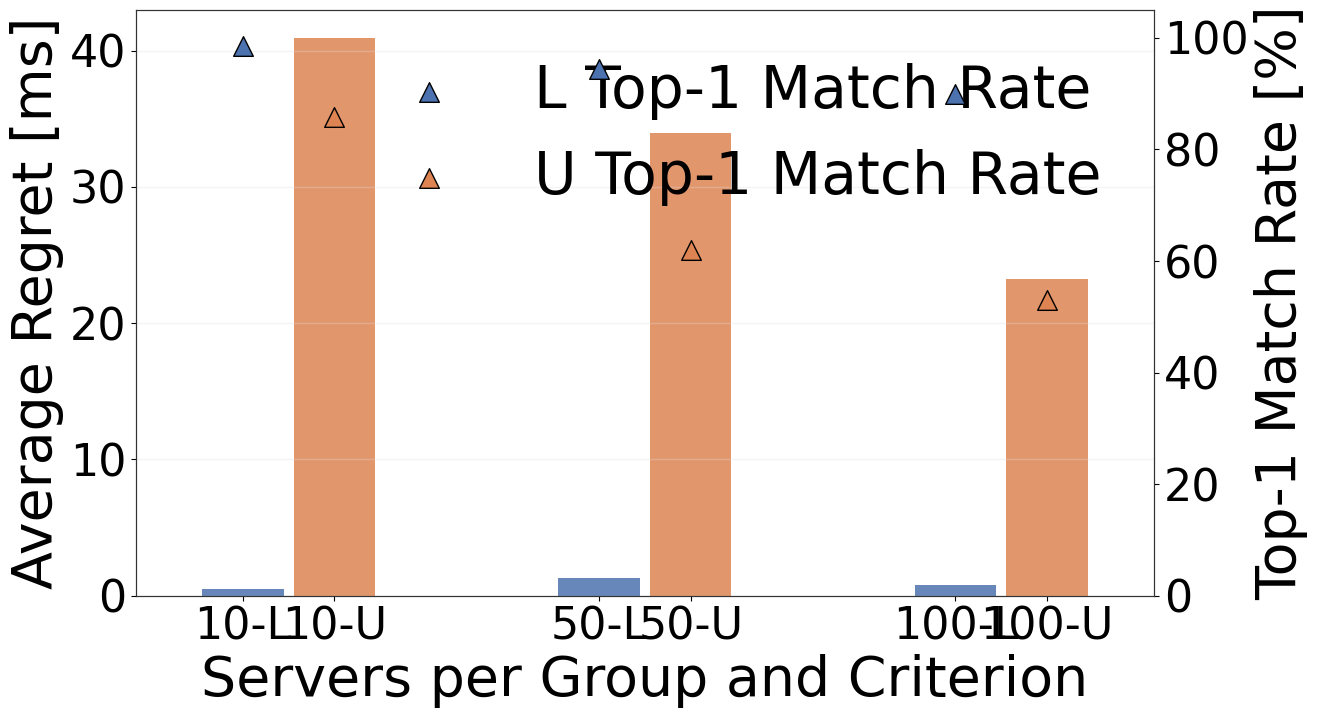

NameError: name 'x' is not defined

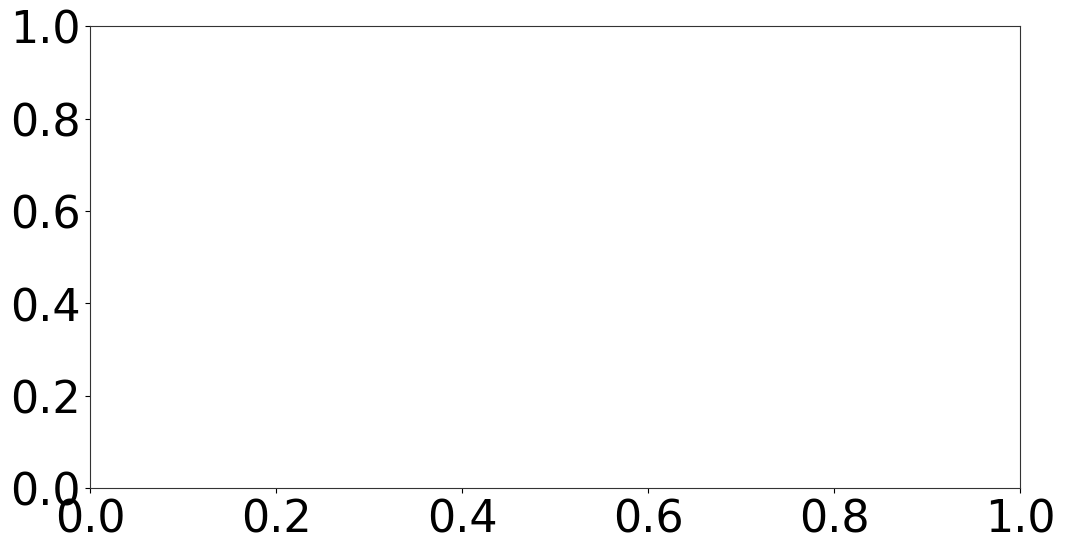

In [15]:
# === density_random1*10*10000.csv Group Analysis Visualization ===
from pathlib import Path
from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 34,
    "axes.labelsize": 40,
    "axes.titlesize": 42,
    "xtick.labelsize": 32,
    "ytick.labelsize": 32,
    "legend.fontsize": 42,
})

CSV_RANDOM_PATH = Path("data/density_random1*10*10000.csv")
GROUP_SIZES = [10, 50, 100]

def prepare_density_frame(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df = df.sort_values(["set_index", "sample_index"]).reset_index(drop=True)

    numeric_cols = [
        "shots",
        "distance",
        "entanglement_speed_factor",
        "gate_speed_factor",
        "zz_time",
    ]
    df[numeric_cols] = df[numeric_cols].astype(float)

    df["zz_time_total_s"] = df["zz_time"] / 1e9

    if (df["entanglement_speed_factor"] == 0).any():
        raise ZeroDivisionError("entanglement_speed_factor must be non-zero.")
    if (df["gate_speed_factor"] == 0).any():
        raise ZeroDivisionError("gate_speed_factor must be non-zero.")

    df["t_distance_per_shot_s"] = 5.0 * df["distance"] / 200000.0
    df["t_entangle_per_shot_s"] = 5.0 / df["entanglement_speed_factor"]
    df["t_gate_per_shot_s"] = 0.0165 / df["gate_speed_factor"]

    per_shot_cols = [
        "t_distance_per_shot_s",
        "t_entangle_per_shot_s",
        "t_gate_per_shot_s",
    ]
    df["L_value_per_shot_s"] = df[per_shot_cols].max(axis=1)
    df["U_value_per_shot_s"] = df[per_shot_cols].sum(axis=1)

    df["L_total_s"] = df["L_value_per_shot_s"] * df["shots"]
    df["U_total_s"] = df["U_value_per_shot_s"] * df["shots"]
    return df

def summarize_groups(df: pd.DataFrame, group_size: int):
    total_groups = len(df) // group_size
    if total_groups == 0:
        raise ValueError(f"Insufficient data for group size {group_size}.")

    trimmed = df.iloc[: total_groups * group_size].copy()
    trimmed["group_id"] = np.arange(len(trimmed)) // group_size

    regrets = {"L": [], "U": []}
    hits = {"L": [], "U": []}

    for _, chunk in trimmed.groupby("group_id"):
        actual = chunk.loc[chunk["zz_time_total_s"].idxmin()]
        row_L = chunk.loc[chunk["L_total_s"].idxmin()]
        row_U = chunk.loc[chunk["U_total_s"].idxmin()]

        regrets["L"].append(abs(row_L["zz_time_total_s"] - actual["zz_time_total_s"]))
        regrets["U"].append(abs(row_U["zz_time_total_s"] - actual["zz_time_total_s"]))
        hits["L"].append(float(row_L["sample_index"] == actual["sample_index"]))
        hits["U"].append(float(row_U["sample_index"] == actual["sample_index"]))

    summary = []
    for criterion in ("L", "U"):
        summary.append(
            {
                "group_size": group_size,
                "criterion": criterion,
                "num_groups": total_groups,
                "mean_regret_s": float(np.mean(regrets[criterion])),
                "hit_rate": float(np.mean(hits[criterion])),
            }
        )
    return summary

df_random = prepare_density_frame(CSV_RANDOM_PATH)

records = []
for size in GROUP_SIZES:
    records.extend(summarize_groups(df_random, size))

metrics_df = pd.DataFrame(records).set_index(["group_size", "criterion"]).sort_index()
metrics_df["mean_regret_ms"] = metrics_df["mean_regret_s"] * 1e3
metrics_df["hit_rate_pct"] = metrics_df["hit_rate"] * 100.0

display(
    metrics_df.reset_index().rename(
        columns={
            "group_size": "Servers per Group",
            "criterion": "Criterion",
            "num_groups": "Group Count",
            "mean_regret_ms": "Average Regret [ms]",
            "hit_rate_pct": "Top-1 Match Rate [%]",
        }
    )[
        [
            "Servers per Group",
            "Criterion",
            "Group Count",
            "Average Regret [ms]",
            "Top-1 Match Rate [%]",
        ]
    ]
)

fig, ax_regret = plt.subplots(figsize=(14, 8))
ax_hit = ax_regret.twinx()

colors = {"L": "#4C72B0", "U": "#DD8452"}
bar_handles = {}
scatter_handles = {}
positions = []
labels = []

base_positions = np.arange(len(GROUP_SIZES)) * 1.4
offset = 0.18
bar_width = 0.32

for base, size in zip(base_positions, GROUP_SIZES):
    for criterion, shift in (("L", -offset), ("U", offset)):
        metrics = metrics_df.loc[(size, criterion)]
        pos = base + shift
        positions.append(pos)
        labels.append(f"{size}-{criterion}")

        bar = ax_regret.bar(
            pos,
            metrics["mean_regret_ms"],
            width=bar_width,
            color=colors[criterion],
            alpha=0.85,
            label=f"{criterion} Average Regret" if criterion not in bar_handles else None,
        )[0]
        if criterion not in bar_handles:
            bar_handles[criterion] = bar

        scatter = ax_hit.scatter(
            pos,
            metrics["hit_rate_pct"],
            s=200,
            color=colors[criterion],
            marker="^",
            edgecolor="black",
            linewidth=1.0,
            label=f"{criterion} Top-1 Match Rate" if criterion not in scatter_handles else None,
        )
        if criterion not in scatter_handles:
            scatter_handles[criterion] = scatter

ax_regret.set_xticks(positions)
ax_regret.set_xticklabels(labels)
ax_regret.set_xlim(base_positions[0] - 0.6, base_positions[-1] + 0.6)
ax_regret.set_xlabel("Servers per Group and Criterion")
ax_regret.set_ylabel("Average Regret [ms]")
ax_hit.set_ylabel("Top-1 Match Rate [%]")
ax_hit.set_ylim(0, 105)
ax_regret.grid(axis="y", alpha=0.3)

legend_handles = list(bar_handles.values()) + list(scatter_handles.values())
legend_labels = [handle.get_label() for handle in legend_handles]
ax_regret.legend(legend_handles, legend_labels, loc="upper right", frameon=False)

plt.tight_layout()
plt.show()

# Separate figure: Regret Rate [%]
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(x, pivot_df["L Regret Rate [%]"], label="$T_{min}$", color="#4C72B0", linewidth=3)
ax.plot(x, pivot_df["U Regret Rate [%]"], label="$T_{max}$", color="#DD8452", linewidth=3)
ax.set_xlabel("Servers per Group")
ax.set_ylabel("Regret Rate [%]")
ax.grid(alpha=1.0)
leg = ax.legend(frameon=True, loc="upper right", bbox_to_anchor=(1, 0.40),
                 facecolor='white', edgecolor='black', framealpha=1.0)
leg.get_frame().set_linewidth(1.2)
plt.tight_layout()
plt.show()

# Separate figure: Top-1 Match Rate [%]
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(x, pivot_df["L Top-1 Match Rate [%]"], label="$T_{min}$", color="#4C72B0", linewidth=3)
ax.plot(x, pivot_df["U Top-1 Match Rate [%]"], label="$T_{max}$", color="#DD8452", linewidth=3)
ax.set_xlabel("Servers per Group")
ax.set_ylabel("Top-1 Match Rate [%]")
ax.set_ylim(0, 105)
ax.grid(alpha=1.0)
ax.legend(frameon=False, loc="upper right", bbox_to_anchor=(1, 0.40))
plt.tight_layout()
plt.show()


group_size=  1, groups=10000, L_regret=0.000000 ms, U_regret=0.000000 ms, L_hit=100.00% , U_hit=100.00%
group_size=  2, groups=5000, L_regret=0.618564 ms, U_regret=96.534475 ms, L_hit=99.50% , U_hit=95.40%
group_size=  3, groups=3333, L_regret=0.283108 ms, U_regret=66.346582 ms, L_hit=99.55% , U_hit=94.15%
group_size=  4, groups=2500, L_regret=0.537604 ms, U_regret=73.153537 ms, L_hit=99.00% , U_hit=92.04%
group_size=  5, groups=2000, L_regret=0.313934 ms, U_regret=53.431440 ms, L_hit=99.05% , U_hit=90.40%
group_size=  6, groups=1666, L_regret=0.457135 ms, U_regret=43.577868 ms, L_hit=98.86% , U_hit=90.70%
group_size=  7, groups=1428, L_regret=0.592899 ms, U_regret=42.501930 ms, L_hit=98.60% , U_hit=88.87%
group_size=  8, groups=1250, L_regret=0.590028 ms, U_regret=42.903974 ms, L_hit=98.24% , U_hit=88.48%
group_size=  9, groups=1111, L_regret=0.533044 ms, U_regret=38.641492 ms, L_hit=98.38% , U_hit=87.40%
group_size= 10, groups=1000, L_regret=0.509373 ms, U_regret=40.942357 ms, L_hit=

,Servers per Group,Group Count,L Average Regret [ms],U Average Regret [ms],L Top-1 Match Rate [%],U Top-1 Match Rate [%]
0,1,10000,0.000000,0.000000,100.000000,100.000000
1,2,5000,0.618564,96.534475,99.500000,95.400000
2,3,3333,0.283108,66.346582,99.549955,94.149415
3,4,2500,0.537604,73.153537,99.000000,92.040000
4,5,2000,0.313934,53.431440,99.050000,90.400000
...,...,...,...,...,...,...
295,296,33,8.598607,22.382973,78.787879,30.303030
296,297,33,7.052751,19.968966,84.848485,33.333333
297,298,33,5.992316,22.767426,87.878788,36.363636
298,299,33,6.255448,22.150304,84.848485,39.393939


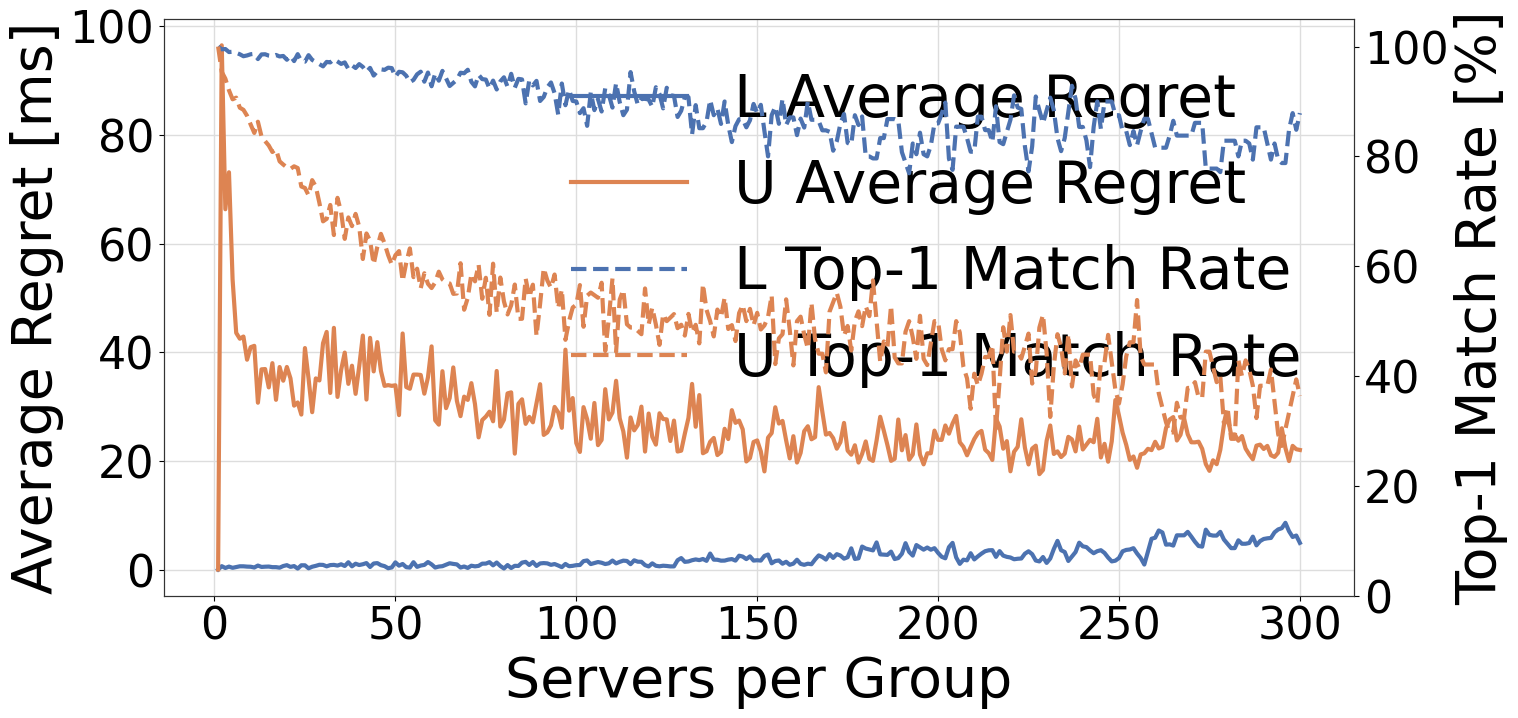

In [24]:
# === density_random1*10*10000.csv Regret by Group Size (1-100) ===
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 34,
    "axes.labelsize": 40,
    "axes.titlesize": 42,
    "xtick.labelsize": 32,
    "ytick.labelsize": 32,
    "legend.fontsize": 42,
})

CSV_RANDOM_PATH = Path("data/density_random1*10*10000.csv")
MAX_GROUP_SIZE = 300

def prepare_density_frame(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df = df.sort_values(["set_index", "sample_index"]).reset_index(drop=True)
    numeric_cols = [
        "shots",
        "distance",
        "entanglement_speed_factor",
        "gate_speed_factor",
        "zz_time",
    ]
    df[numeric_cols] = df[numeric_cols].astype(float)

    df["zz_time_total_s"] = df["zz_time"] / 1e9

    if (df["entanglement_speed_factor"] == 0).any():
        raise ZeroDivisionError("entanglement_speed_factor must be non-zero.")
    if (df["gate_speed_factor"] == 0).any():
        raise ZeroDivisionError("gate_speed_factor must be non-zero.")

    df["t_distance_per_shot_s"] = 5.0 * df["distance"] / 200000.0
    df["t_entangle_per_shot_s"] = 5.0 / df["entanglement_speed_factor"]
    df["t_gate_per_shot_s"] = 0.0165 / df["gate_speed_factor"]

    per_shot_cols = [
        "t_distance_per_shot_s",
        "t_entangle_per_shot_s",
        "t_gate_per_shot_s",
    ]
    df["L_value_per_shot_s"] = df[per_shot_cols].max(axis=1)
    df["U_value_per_shot_s"] = df[per_shot_cols].sum(axis=1)

    df["L_total_s"] = df["L_value_per_shot_s"] * df["shots"]
    df["U_total_s"] = df["U_value_per_shot_s"] * df["shots"]
    return df

def average_regret_by_group(df: pd.DataFrame, group_size: int):
    total_groups = len(df) // group_size
    if total_groups == 0:
        return np.nan, np.nan, 0, np.nan, np.nan

    trimmed = df.iloc[: total_groups * group_size].copy()
    trimmed["group_id"] = np.arange(len(trimmed)) // group_size

    regrets_L = []
    regrets_U = []
    hits_L = []
    hits_U = []

    for _, chunk in trimmed.groupby("group_id"):
        actual = chunk.loc[chunk["zz_time_total_s"].idxmin()]
        row_L = chunk.loc[chunk["L_total_s"].idxmin()]
        row_U = chunk.loc[chunk["U_total_s"].idxmin()]
        regrets_L.append(abs(row_L["zz_time_total_s"] - actual["zz_time_total_s"]))
        regrets_U.append(abs(row_U["zz_time_total_s"] - actual["zz_time_total_s"]))
        hits_L.append(float(row_L["sample_index"] == actual["sample_index"]))
        hits_U.append(float(row_U["sample_index"] == actual["sample_index"]))

    return (
        float(np.mean(regrets_L)),
        float(np.mean(regrets_U)),
        total_groups,
        float(np.mean(hits_L)),
        float(np.mean(hits_U)),
    )

df_random = prepare_density_frame(CSV_RANDOM_PATH)

records = []
for size in range(1, MAX_GROUP_SIZE + 1):
    regret_L, regret_U, group_count, hit_L, hit_U = average_regret_by_group(df_random, size)
    if np.isnan(regret_L) or np.isnan(regret_U) or group_count == 0:
        continue

    regret_L_ms = regret_L * 1e3
    regret_U_ms = regret_U * 1e3
    hit_L_pct = hit_L * 100.0
    hit_U_pct = hit_U * 100.0
    records.append(
        {
            "group_size": size,
            "num_groups": group_count,
            "L_regret_ms": regret_L_ms,
            "U_regret_ms": regret_U_ms,
            "L_hit_rate_pct": hit_L_pct,
            "U_hit_rate_pct": hit_U_pct,
        }
    )
    print(
        f"group_size={size:3d}, groups={group_count:4d}, "
        f"L_regret={regret_L_ms:.6f} ms, U_regret={regret_U_ms:.6f} ms, "
        f"L_hit={hit_L_pct:.2f}% , U_hit={hit_U_pct:.2f}%"
    )

summary_df = pd.DataFrame(records)

display(summary_df.rename(columns={
    "group_size": "Servers per Group",
    "num_groups": "Group Count",
    "L_regret_ms": "L Average Regret [ms]",
    "U_regret_ms": "U Average Regret [ms]",
    "L_hit_rate_pct": "L Top-1 Match Rate [%]",
    "U_hit_rate_pct": "U Top-1 Match Rate [%]",
}))

fig, ax_regret = plt.subplots(figsize=(16, 8))
ax_hit = ax_regret.twinx()

ax_regret.plot(
    summary_df["group_size"],
    summary_df["L_regret_ms"],
    label="L Average Regret",
    color="#4C72B0",
    linewidth=3,
)
ax_regret.plot(
    summary_df["group_size"],
    summary_df["U_regret_ms"],
    label="U Average Regret",
    color="#DD8452",
    linewidth=3,
)

ax_hit.plot(
    summary_df["group_size"],
    summary_df["L_hit_rate_pct"],
    label="L Top-1 Match Rate",
    color="#4C72B0",
    linewidth=3,
    linestyle="--",
)
ax_hit.plot(
    summary_df["group_size"],
    summary_df["U_hit_rate_pct"],
    label="U Top-1 Match Rate",
    color="#DD8452",
    linewidth=3,
    linestyle="--",
)

ax_regret.set_xlabel("Servers per Group")
ax_regret.set_ylabel("Average Regret [ms]")
ax_hit.set_ylabel("Top-1 Match Rate [%]")
ax_hit.set_ylim(0, 105)
ax_regret.grid(alpha=1.0)

lines_regret, labels_regret = ax_regret.get_legend_handles_labels()
lines_hit, labels_hit = ax_hit.get_legend_handles_labels()
ax_regret.legend(lines_regret + lines_hit, labels_regret + labels_hit, frameon=False, loc="upper right")

plt.tight_layout()
plt.show()


group_size=  1, groups=10000, criterion=L, regret=0.000000 ms, hit=100.00%
group_size=  1, groups=10000, criterion=U, regret=0.000000 ms, hit=100.00%
group_size=  1, groups=10000, criterion=R, regret=0.000000 ms, hit=100.00%
group_size=  2, groups=5000, criterion=L, regret=0.056483 ms, hit=99.80%
group_size=  2, groups=5000, criterion=U, regret=3.232915 ms, hit=97.72%
group_size=  2, groups=5000, criterion=R, regret=3193.818827 ms, hit=49.38%
group_size=  3, groups=3333, criterion=L, regret=0.096156 ms, hit=99.61%
group_size=  3, groups=3333, criterion=U, regret=6.081593 ms, hit=95.38%
group_size=  3, groups=3333, criterion=R, regret=3982.847040 ms, hit=34.32%
group_size=  4, groups=2500, criterion=L, regret=0.129032 ms, hit=99.28%
group_size=  4, groups=2500, criterion=U, regret=8.154411 ms, hit=92.96%
group_size=  4, groups=2500, criterion=R, regret=4602.823439 ms, hit=25.92%
group_size=  5, groups=2000, criterion=L, regret=0.242039 ms, hit=98.85%
group_size=  5, groups=2000, criteri

,Servers per Group,L Average Regret [ms],Random Average Regret [ms],U Average Regret [ms],L Top-1 Match Rate [%],Random Top-1 Match Rate [%],U Top-1 Match Rate [%]
0,1,0.000000,0.000000,0.000000,100.000000,100.000000,100.000000
1,2,0.056483,3193.818827,3.232915,99.800000,49.380000,97.720000
2,3,0.096156,3982.847040,6.081593,99.609961,34.323432,95.379538
3,4,0.129032,4602.823439,8.154411,99.280000,25.920000,92.960000
4,5,0.242039,4661.294388,10.109920,98.850000,19.050000,91.350000
...,...,...,...,...,...,...,...
195,196,2.283122,6202.950840,9.913312,84.313725,0.000000,33.333333
196,197,1.445847,5284.196789,11.510282,80.000000,0.000000,32.000000
197,198,1.135152,4337.659852,10.946019,84.000000,2.000000,30.000000
198,199,1.093606,4315.765918,9.927370,86.000000,0.000000,32.000000


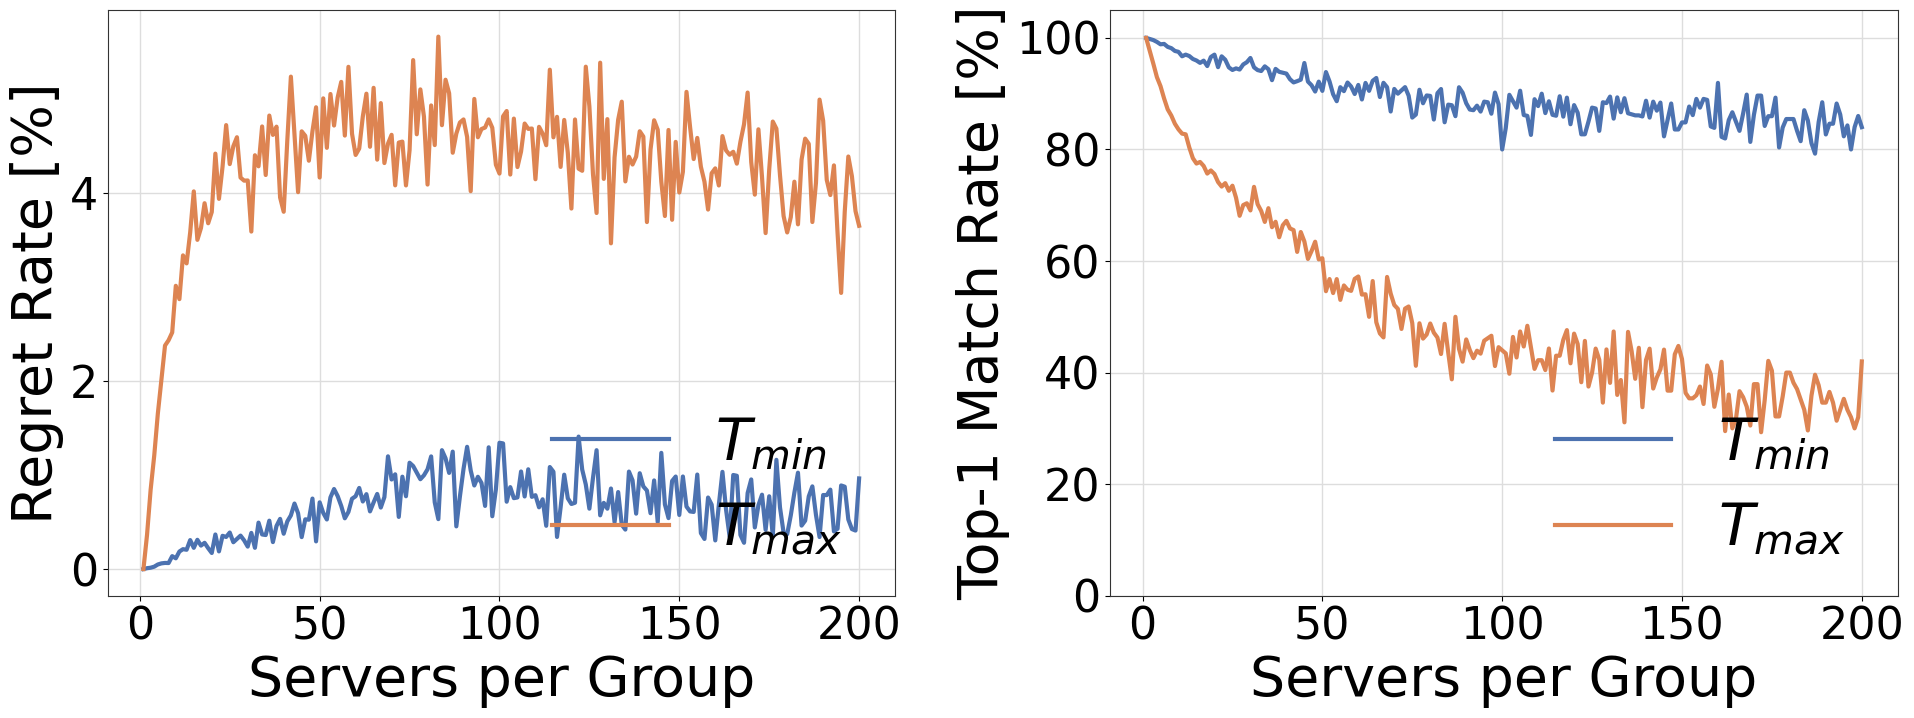

In [20]:
# === density_random1*10*10000.csv Regret & Hit Rate Including Random Baseline ===
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 34,
    "axes.labelsize": 40,
    "axes.titlesize": 42,
    "xtick.labelsize": 32,
    "ytick.labelsize": 32,
    "legend.fontsize": 42,
})

# CSV_RANDOM_PATH = Path("data/density_random1*10*100000.csv")
CSV_RANDOM_PATH = Path("../../data/density_random_cli-1.csv")
MAX_GROUP_SIZE = 200

def prepare_density_frame(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df = df.sort_values(["set_index", "sample_index"]).reset_index(drop=True)
    numeric_cols = [
        "shots",
        "distance",
        "entanglement_speed_factor",
        "gate_speed_factor",
        "zz_time",
    ]
    df[numeric_cols] = df[numeric_cols].astype(float)
    df["zz_time_total_s"] = df["zz_time"] / 1e9

    if (df["entanglement_speed_factor"] == 0).any():
        raise ZeroDivisionError("entanglement_speed_factor must be non-zero.")
    if (df["gate_speed_factor"] == 0).any():
        raise ZeroDivisionError("gate_speed_factor must be non-zero.")

    df["t_distance_per_shot_s"] = 5.0 * df["distance"] / 200000.0
    df["t_entangle_per_shot_s"] = 5.0 / df["entanglement_speed_factor"]
    # df["t_gate_per_shot_s"] = 0.0165 / df["gate_speed_factor"]
    df["t_gate_per_shot_s"] = 0.008745 / df["gate_speed_factor"]

    per_shot_cols = [
        "t_distance_per_shot_s",
        "t_entangle_per_shot_s",
        "t_gate_per_shot_s",
    ]
    df["L_value_per_shot_s"] = df[per_shot_cols].max(axis=1)
    df["U_value_per_shot_s"] = df[per_shot_cols].sum(axis=1)

    df["L_total_s"] = df["L_value_per_shot_s"] * df["shots"]
    df["U_total_s"] = df["U_value_per_shot_s"] * df["shots"]
    return df

def compute_metrics_for_group(chunk: pd.DataFrame, rng: np.random.Generator):
    actual = chunk.loc[chunk["zz_time_total_s"].idxmin()]
    row_L = chunk.loc[chunk["L_total_s"].idxmin()]
    row_U = chunk.loc[chunk["U_total_s"].idxmin()]
    random_row = chunk.iloc[rng.integers(len(chunk))]

    metrics = {
        "L": {
            "regret": abs(row_L["zz_time_total_s"] - actual["zz_time_total_s"]),
            "hit": float(row_L["sample_index"] == actual["sample_index"]),
        },
        "U": {
            "regret": abs(row_U["zz_time_total_s"] - actual["zz_time_total_s"]),
            "hit": float(row_U["sample_index"] == actual["sample_index"]),
        },
        "R": {
            "regret": abs(random_row["zz_time_total_s"] - actual["zz_time_total_s"]),
            "hit": float(random_row["sample_index"] == actual["sample_index"]),
        },
    }
    return metrics

def summarize_over_group_sizes(df: pd.DataFrame, max_group_size: int, seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    records = []
    for size in range(1, max_group_size + 1):
        total_groups = len(df) // size
        if total_groups == 0:
            continue

        trimmed = df.iloc[: total_groups * size].copy()
        trimmed["group_id"] = np.arange(len(trimmed)) // size

        stats = {key: {"regret": [], "hit": []} for key in ("L", "U", "R")}
        for _, chunk in trimmed.groupby("group_id"):
            metrics = compute_metrics_for_group(chunk, rng)
            for key in ("L", "U", "R"):
                stats[key]["regret"].append(metrics[key]["regret"])
                stats[key]["hit"].append(metrics[key]["hit"])

        for key in ("L", "U", "R"):
            regret_ms = float(np.mean(stats[key]["regret"]) * 1e3)
            hit_pct = float(np.mean(stats[key]["hit"]) * 100.0)
            records.append(
                {
                    "group_size": size,
                    "criterion": key,
                    "group_count": total_groups,
                    "avg_regret_ms": regret_ms,
                    "top1_match_pct": hit_pct,
                }
            )
            print(
                f"group_size={size:3d}, groups={total_groups:4d}, criterion={key}, "
                f"regret={regret_ms:.6f} ms, hit={hit_pct:.2f}%"
            )

    return pd.DataFrame(records)


df_random = prepare_density_frame(CSV_RANDOM_PATH)

summary_df = summarize_over_group_sizes(df_random, MAX_GROUP_SIZE)

pivot_df = summary_df.pivot(index="group_size", columns="criterion", values=["avg_regret_ms", "top1_match_pct"])
pivot_df.columns = [f"{metric}_{criterion}" for metric, criterion in pivot_df.columns]
pivot_df = pivot_df.reset_index().rename(columns={"group_size": "Servers per Group", "avg_regret_ms_L": "L Average Regret [ms]", "avg_regret_ms_U": "U Average Regret [ms]", "avg_regret_ms_R": "Random Average Regret [ms]", "top1_match_pct_L": "L Top-1 Match Rate [%]", "top1_match_pct_U": "U Top-1 Match Rate [%]", "top1_match_pct_R": "Random Top-1 Match Rate [%]",})

display(pivot_df)

# Add regret rate [%] per group size and merge into pivot_df
records = []
for size in range(1, MAX_GROUP_SIZE + 1):
    total_groups = len(df_random) // size
    if total_groups == 0:
        continue
    trimmed = df_random.iloc[: total_groups * size].copy()
    trimmed['group_id'] = np.arange(len(trimmed)) // size
    rates_L, rates_U = [], []
    for _, chunk in trimmed.groupby('group_id'):
        idx_actual = chunk['zz_time_total_s'].idxmin()
        idx_L = chunk['L_total_s'].idxmin()
        idx_U = chunk['U_total_s'].idxmin()
        actual_t = float(df_random.loc[idx_actual, 'zz_time_total_s'])
        candL_t = float(df_random.loc[idx_L, 'zz_time_total_s'])
        candU_t = float(df_random.loc[idx_U, 'zz_time_total_s'])
        if actual_t > 0:
            rates_L.append(abs(candL_t - actual_t) / actual_t * 100.0)
            rates_U.append(abs(candU_t - actual_t) / actual_t * 100.0)
    if rates_L or rates_U:
        records.append({
            'Servers per Group': size,
            'L Regret Rate [%]': float(np.mean(rates_L)) if rates_L else np.nan,
            'U Regret Rate [%]': float(np.mean(rates_U)) if rates_U else np.nan,
        })
rr_df = pd.DataFrame.from_records(records)
pivot_df = pivot_df.merge(rr_df, on='Servers per Group', how='left')

fig, (ax_regret, ax_hit) = plt.subplots(1, 2, figsize=(20, 8), sharex=True)

x = pivot_df["Servers per Group"]
ax_regret.plot(x, pivot_df["L Regret Rate [%]"], label="$T_{min}$", color="#4C72B0", linewidth=3)
ax_regret.plot(x, pivot_df["U Regret Rate [%]"], label="$T_{max}$", color="#DD8452", linewidth=3)
ax_regret.set_xlabel("Servers per Group")
ax_regret.set_ylabel("Regret Rate [%]")
ax_regret.grid(alpha=1.0)
ax_regret.legend(frameon=False, loc="upper right", bbox_to_anchor=(1, 0.40))

ax_hit.plot(x, pivot_df["L Top-1 Match Rate [%]"], label="$T_{min}$", color="#4C72B0", linewidth=3)
ax_hit.plot(x, pivot_df["U Top-1 Match Rate [%]"], label="$T_{max}$", color="#DD8452", linewidth=3)
ax_hit.set_xlabel("Servers per Group")
ax_hit.set_ylabel("Top-1 Match Rate [%]")
ax_hit.set_ylim(0, 105)
ax_hit.grid(alpha=1.0)
ax_hit.legend(frameon=False, loc="upper right", bbox_to_anchor=(1, 0.40))

plt.tight_layout()
plt.show()


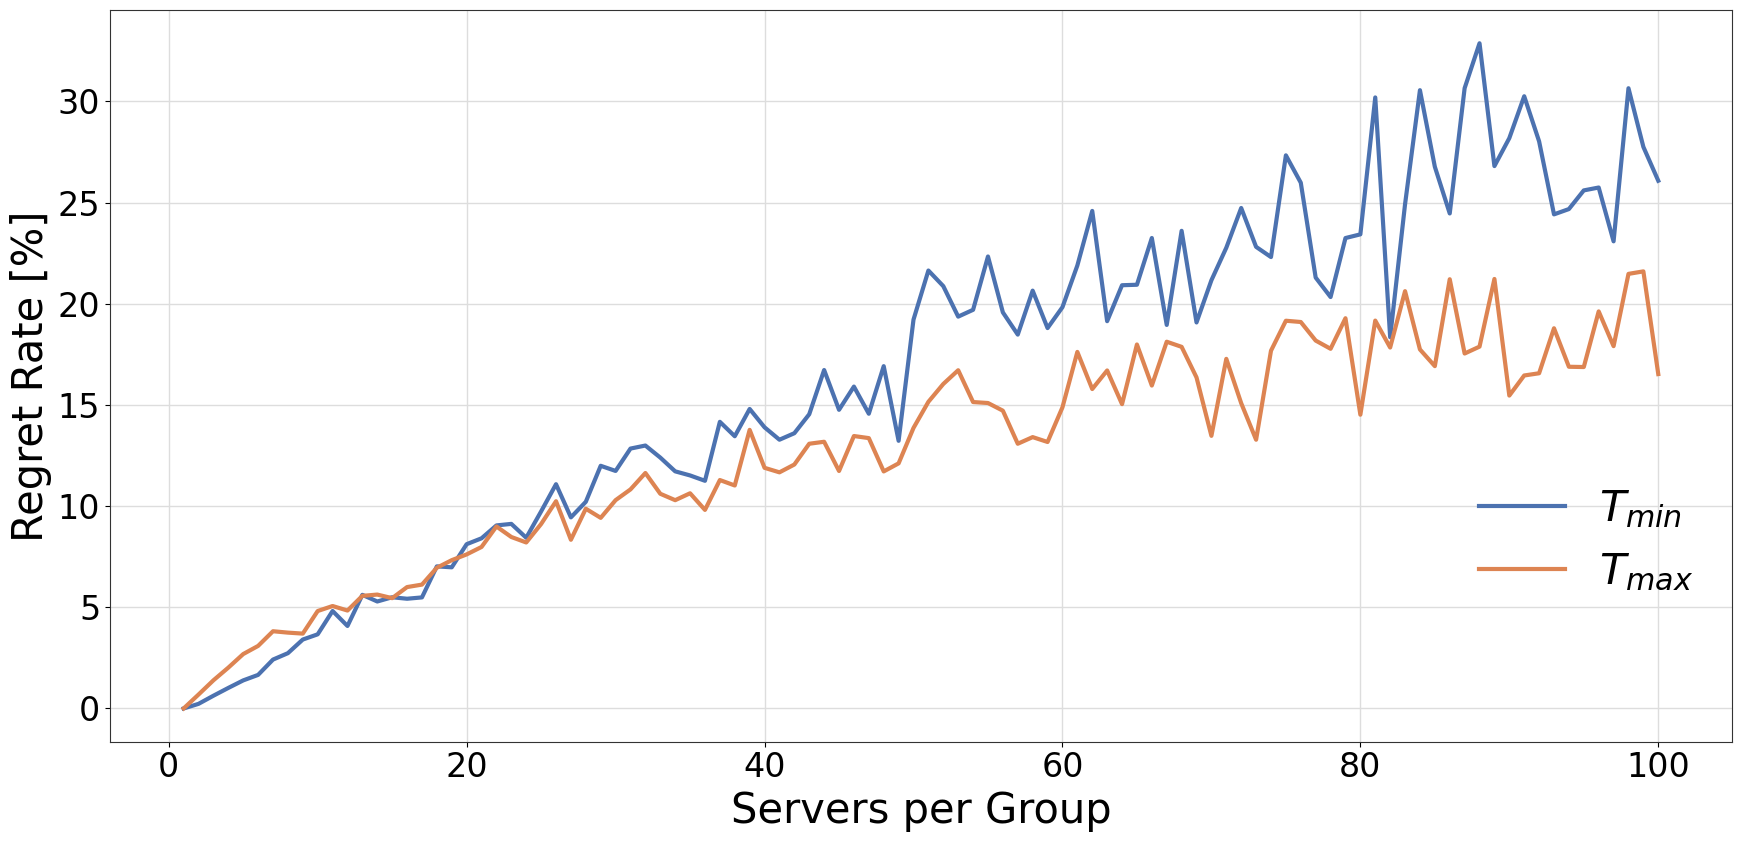

In [ ]:
# Regret Rate vs Actual Optimum (L/U only)
# 直前セルで作成した df_random / MAX_GROUP_SIZE を利用します。
# 各 group_size ごとに、実測最速 (actual=最小 zz_time_total_s) を基準として
# 後悔率 [%] = |zz_time_total_s(candidate) - actual| / actual * 100 を平均化して描画します。

import numpy as np, pandas as pd, matplotlib.pyplot as plt

def summarize_regret_rate(df: pd.DataFrame, max_group_size: int) -> pd.DataFrame:
    records = []
    for size in range(1, max_group_size + 1):
        total_groups = len(df) // size
        if total_groups == 0:
            continue
        trimmed = df.iloc[: total_groups * size].copy()
        trimmed['group_id'] = np.arange(len(trimmed)) // size

        rates_L, rates_U = [], []
        for _, chunk in trimmed.groupby('group_id'):
            # 実測の最適 (actual) と L/U 候補の行を取得
            idx_actual = chunk['zz_time_total_s'].idxmin()
            idx_L = chunk['L_total_s'].idxmin()
            idx_U = chunk['U_total_s'].idxmin()
            actual_t = float(df.loc[idx_actual, 'zz_time_total_s'])
            candL_t = float(df.loc[idx_L, 'zz_time_total_s'])
            candU_t = float(df.loc[idx_U, 'zz_time_total_s'])
            if actual_t > 0:
                rates_L.append(abs(candL_t - actual_t) / actual_t * 100.0)
                rates_U.append(abs(candU_t - actual_t) / actual_t * 100.0)
        if rates_L or rates_U:
            records.append({
                'group_size': size,
                'L_regret_rate_pct': float(np.mean(rates_L)) if rates_L else np.nan,
                'U_regret_rate_pct': float(np.mean(rates_U)) if rates_U else np.nan,
            })
    return pd.DataFrame.from_records(records)

# 計算
rr_df = summarize_regret_rate(df_random, MAX_GROUP_SIZE)

# 可視化
fig, ax = plt.subplots(figsize=(18, 9))
x = rr_df['group_size']
ax.plot(x, rr_df['L_regret_rate_pct'], label='$T_{min}$', color='#4C72B0', linewidth=3)
ax.plot(x, rr_df['U_regret_rate_pct'], label='$T_{max}$', color='#DD8452', linewidth=3)
ax.set_xlabel('Servers per Group')
ax.set_ylabel('Regret Rate [%]')
ax.grid(alpha=1.0)
ax.legend(frameon=False, loc='upper right',bbox_to_anchor=(1, 0.40))

plt.tight_layout()
plt.show()

# python density_random.py --spec shots=10 --sets 1 --samples 100000 --overwrite

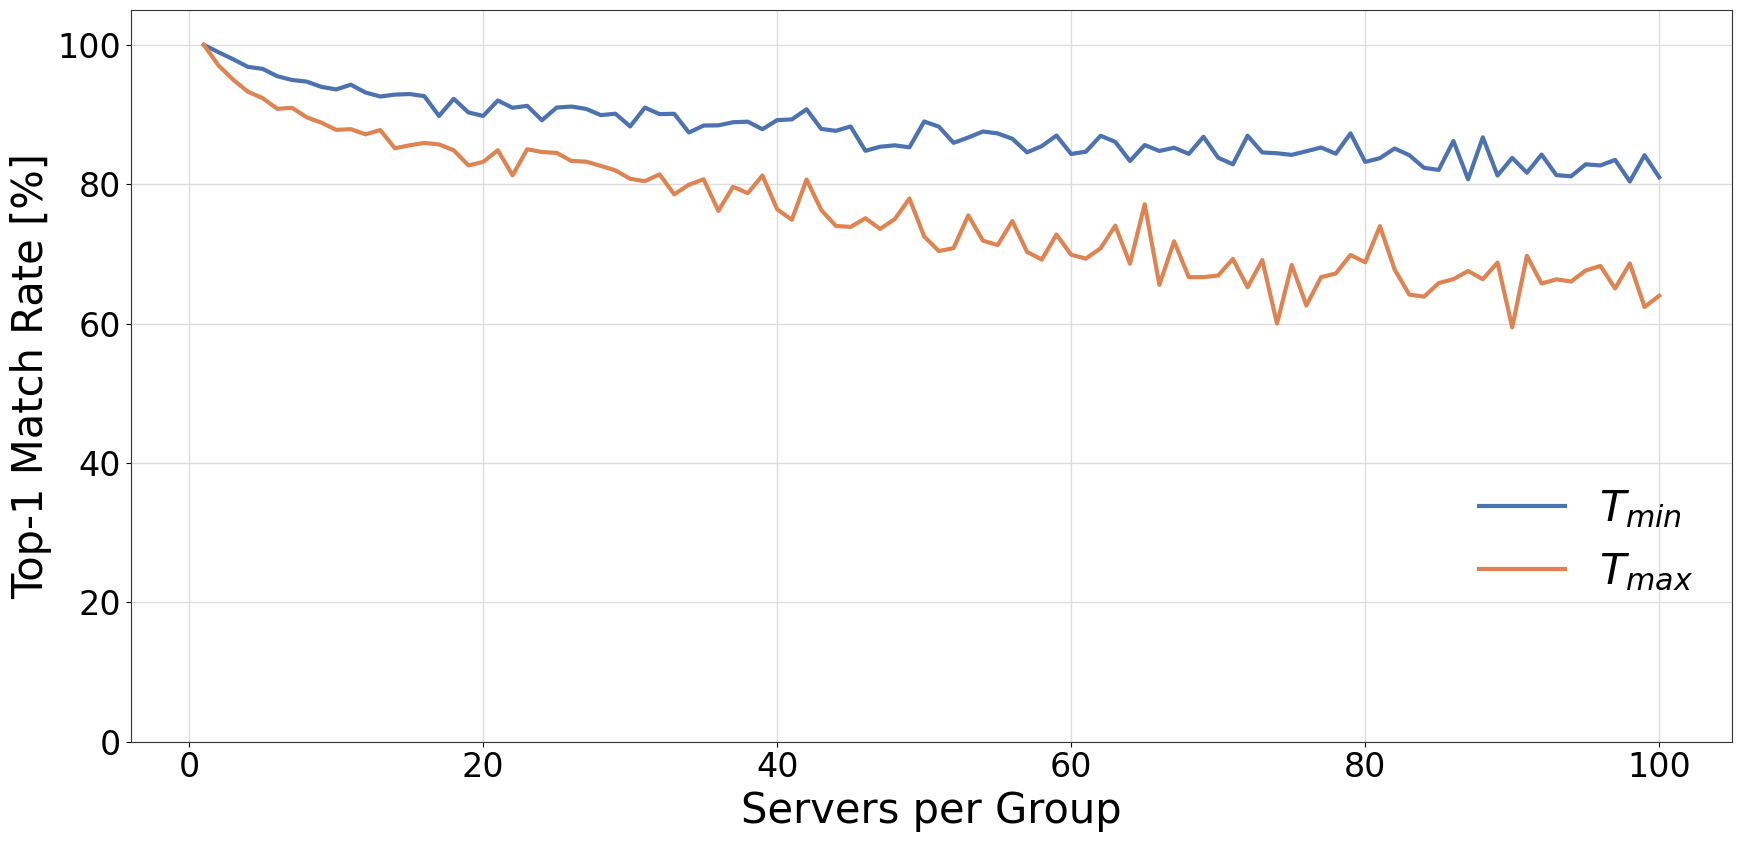

In [ ]:
# Top-1 Match Rate only figure
fig, ax = plt.subplots(figsize=(18, 9))
x = pivot_df['Servers per Group']
ax.plot(x, pivot_df["L Top-1 Match Rate [%]"], label="$T_{min}$", color="#4C72B0", linewidth=3)
ax.plot(x, pivot_df["U Top-1 Match Rate [%]"], label="$T_{max}$", color="#DD8452", linewidth=3)
ax.set_xlabel('Servers per Group')
ax.set_ylabel('Top-1 Match Rate [%]')
ax.set_ylim(0, 105)
ax.grid(alpha=1.0)
ax.legend(frameon=False, loc='upper right', bbox_to_anchor=(1, 0.40))
plt.tight_layout()
plt.show()


In [16]:
# Regret and Top-1 with 95% Bootstrap CI
import numpy as np, pandas as pd, matplotlib.pyplot as plt

def bootstrap_ci_mean(values, n_boot=2000, alpha=0.05, seed=42):
    arr = np.asarray(values, dtype=float)
    n = len(arr)
    if n == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    boot_means = np.empty(n_boot, dtype=float)
    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot_means[b] = arr[idx].mean()
    lo = np.percentile(boot_means, 2.5)
    hi = np.percentile(boot_means, 97.5)
    return float(arr.mean()), float(lo), float(hi)

def summarize_regret_rate_bootstrap(df: pd.DataFrame, max_group_size: int, n_boot=2000, seed=42) -> pd.DataFrame:
    records = []
    for size in range(1, max_group_size + 1):
        total_groups = len(df) // size
        if total_groups == 0:
            continue
        trimmed = df.iloc[: total_groups * size].copy()
        trimmed['group_id'] = np.arange(len(trimmed)) // size
        rates_L, rates_U = [], []
        for _, chunk in trimmed.groupby('group_id'):
            row_actual = chunk.loc[chunk['zz_time_total_s'].idxmin()]
            row_L = chunk.loc[chunk['L_total_s'].idxmin()]
            row_U = chunk.loc[chunk['U_total_s'].idxmin()]
            actual_t = float(row_actual['zz_time_total_s'])
            candL_t = float(row_L['zz_time_total_s'])
            candU_t = float(row_U['zz_time_total_s'])
            if actual_t > 0:
                rates_L.append(abs(candL_t - actual_t) / actual_t * 100.0)
                rates_U.append(abs(candU_t - actual_t) / actual_t * 100.0)
        Lm, Llo, Lhi = bootstrap_ci_mean(rates_L, n_boot=n_boot, seed=seed + size * 101 + 1)
        Um, Ulo, Uhi = bootstrap_ci_mean(rates_U, n_boot=n_boot, seed=seed + size * 101 + 2)
        records.append({
            'group_size': size,
            'L_mean': Lm, 'L_lo': Llo, 'L_hi': Lhi,
            'U_mean': Um, 'U_lo': Ulo, 'U_hi': Uhi,
        })
    return pd.DataFrame.from_records(records)

def summarize_top1_bootstrap(df: pd.DataFrame, max_group_size: int, n_boot=2000, seed=42) -> pd.DataFrame:
    records = []
    for size in range(1, max_group_size + 1):
        total_groups = len(df) // size
        if total_groups == 0:
            continue
        trimmed = df.iloc[: total_groups * size].copy()
        trimmed['group_id'] = np.arange(len(trimmed)) // size
        hits_L, hits_U = [], []
        for _, chunk in trimmed.groupby('group_id'):
            idx_actual = chunk['zz_time_total_s'].idxmin()
            idx_L = chunk['L_total_s'].idxmin()
            idx_U = chunk['U_total_s'].idxmin()
            hits_L.append(float(chunk.loc[idx_L, 'sample_index'] == chunk.loc[idx_actual, 'sample_index']))
            hits_U.append(float(chunk.loc[idx_U, 'sample_index'] == chunk.loc[idx_actual, 'sample_index']))
        mL, loL, hiL = bootstrap_ci_mean(hits_L, n_boot=n_boot, seed=seed + size * 101 + 3)
        mU, loU, hiU = bootstrap_ci_mean(hits_U, n_boot=n_boot, seed=seed + size * 101 + 4)
        records.append({
            'group_size': size,
            'L_mean_pct': mL * 100.0, 'L_lo_pct': loL * 100.0, 'L_hi_pct': hiL * 100.0,
            'U_mean_pct': mU * 100.0, 'U_lo_pct': loU * 100.0, 'U_hi_pct': hiU * 100.0,
        })
    return pd.DataFrame.from_records(records)

# Compute bootstrap summaries
rr_ci_df = summarize_regret_rate_bootstrap(df_random, MAX_GROUP_SIZE, n_boot=2000, seed=42)
t1_ci_df = summarize_top1_bootstrap(df_random, MAX_GROUP_SIZE, n_boot=2000, seed=42)

# Plot: Regret Rate with 95% Bootstrap CI
fig, ax = plt.subplots(figsize=(18, 9))
x = rr_ci_df['group_size']
ax.plot(x, rr_ci_df['L_mean'], label='$T_{min}$', color='#4C72B0', linewidth=3)
ax.fill_between(x, rr_ci_df['L_lo'], rr_ci_df['L_hi'], color='#4C72B0', alpha=0.2)
ax.plot(x, rr_ci_df['U_mean'], label='$T_{max}$', color='#DD8452', linewidth=3)
ax.fill_between(x, rr_ci_df['U_lo'], rr_ci_df['U_hi'], color='#DD8452', alpha=0.2)
ax.set_xlabel('Servers per Group')
ax.set_ylabel('Regret Rate [%]')
ax.grid(alpha=1.0)
ax.legend(frameon=False, loc='upper right', bbox_to_anchor=(1, 0.40))
plt.tight_layout()
plt.show()

# Plot: Top-1 Match Rate with 95% Bootstrap CI
fig, ax = plt.subplots(figsize=(18, 9))
x = t1_ci_df['group_size']
ax.plot(x, t1_ci_df['L_mean_pct'], label='$T_{min}$', color='#4C72B0', linewidth=3)
ax.fill_between(x, t1_ci_df['L_lo_pct'], t1_ci_df['L_hi_pct'], color='#4C72B0', alpha=0.2)
ax.plot(x, t1_ci_df['U_mean_pct'], label='$T_{max}$', color='#DD8452', linewidth=3)
ax.fill_between(x, t1_ci_df['U_lo_pct'], t1_ci_df['U_hi_pct'], color='#DD8452', alpha=0.2)
ax.set_xlabel('Servers per Group')
ax.set_ylabel('Top-1 Match Rate [%]')
ax.set_ylim(0, 105)
ax.grid(alpha=1.0)
ax.legend(frameon=False, loc='upper right', bbox_to_anchor=(1, 0.40))
plt.tight_layout()
plt.show()


NameError: name 'MAX_GROUP_SIZE' is not defined

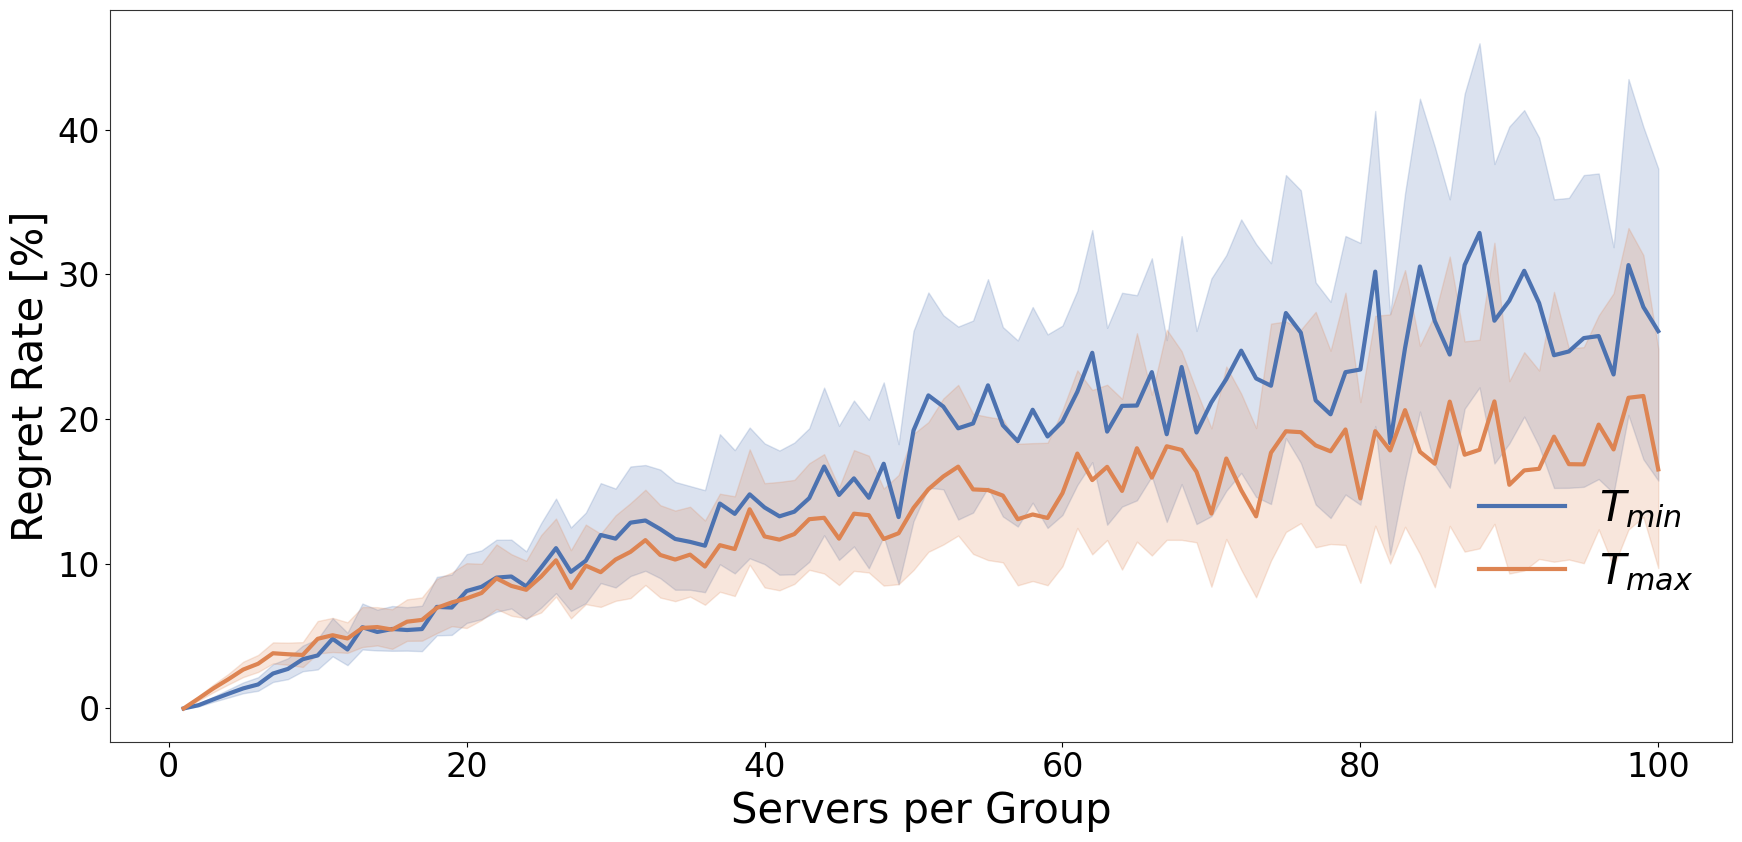

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Use latest randomized density dataset
CSV_RANDOM_PATH = Path("data/density_random.csv")
MAX_GROUP_SIZE = 100

# Requires prepare_density_frame and summarize_regret_rate_bootstrap defined above
df_random = prepare_density_frame(CSV_RANDOM_PATH)
rr_ci_df = summarize_regret_rate_bootstrap(df_random, MAX_GROUP_SIZE, n_boot=2000, seed=42)

# Plot: Regret Rate with 95% Bootstrap CI
fig, ax = plt.subplots(figsize=(18, 9))
x = rr_ci_df['group_size']
ax.plot(x, rr_ci_df['L_mean'], label=r"$T_{min}$", color="#4C72B0", linewidth=3)
ax.fill_between(x, rr_ci_df['L_lo'], rr_ci_df['L_hi'], color="#4C72B0", alpha=0.2)
ax.plot(x, rr_ci_df['U_mean'], label=r"$T_{max}$", color="#DD8452", linewidth=3)
ax.fill_between(x, rr_ci_df['U_lo'], rr_ci_df['U_hi'], color="#DD8452", alpha=0.2)
ax.set_xlabel("Servers per Group")
ax.set_ylabel("Regret Rate [%]")
plt.grid(False)
ax.legend(frameon=False, loc="upper right", bbox_to_anchor=(1, 0.40))
plt.tight_layout()
plt.show()


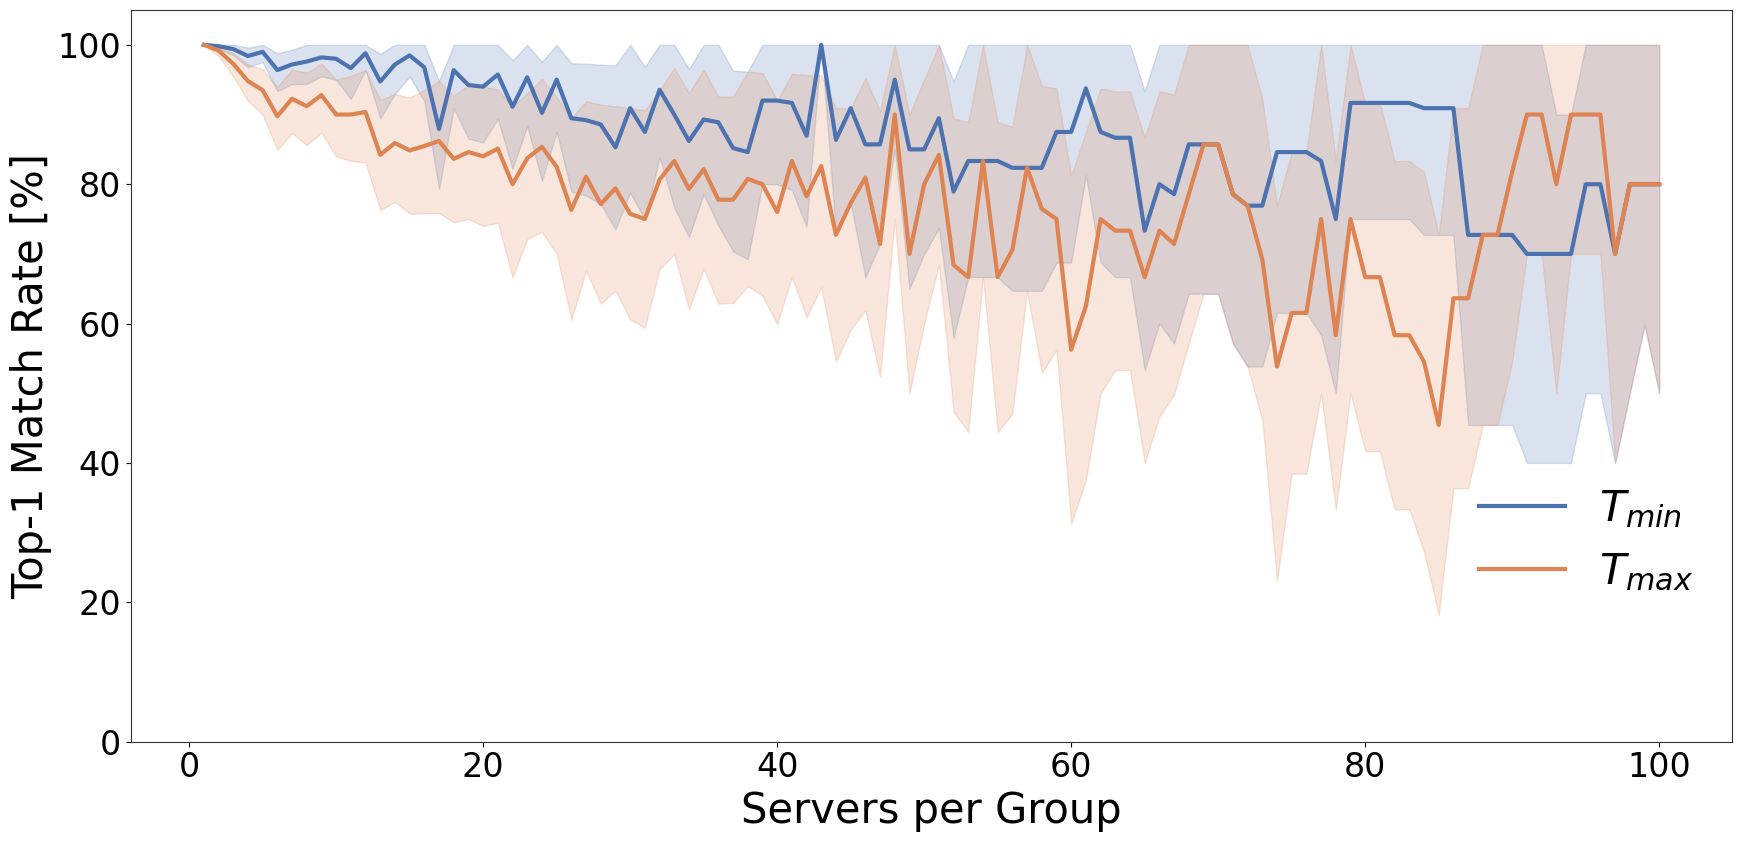

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Use latest randomized density dataset
CSV_RANDOM_PATH = Path("../../data/density_random.csv")
MAX_GROUP_SIZE = 100

# Requires prepare_density_frame and summarize_top1_bootstrap defined above
df_random = prepare_density_frame(CSV_RANDOM_PATH)
t1_ci_df = summarize_top1_bootstrap(df_random, MAX_GROUP_SIZE, n_boot=2000, seed=42)

# Plot: Top-1 Match Rate with 95% Bootstrap CI
fig, ax = plt.subplots(figsize=(18, 9))
x = t1_ci_df['group_size']
ax.plot(x, t1_ci_df['L_mean_pct'], label=r"$T_{min}$", color="#4C72B0", linewidth=3)
ax.fill_between(x, t1_ci_df['L_lo_pct'], t1_ci_df['L_hi_pct'], color="#4C72B0", alpha=0.2)
ax.plot(x, t1_ci_df['U_mean_pct'], label=r"$T_{max}$", color="#DD8452", linewidth=3)
ax.fill_between(x, t1_ci_df['U_lo_pct'], t1_ci_df['U_hi_pct'], color="#DD8452", alpha=0.2)
ax.set_xlabel("Servers per Group")
ax.set_ylabel("Top-1 Match Rate [%]")
ax.set_ylim(0, 105)
plt.grid(False)
leg = ax.legend(frameon=True, loc="upper right", bbox_to_anchor=(1, 0.40),
                 facecolor='white', edgecolor='black', framealpha=1.0)
leg.get_frame().set_linewidth(1.2)
plt.tight_layout()
plt.show()


In [ ]:
# === Export compact CSV summaries from density_random ===
from pathlib import Path
import pandas as pd

CSV_RANDOM_PATH = Path('data/density_random.csv')
OUT_DIR = Path('data')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Ensure base frame
try:
    df_random
except NameError:
    df_random = prepare_density_frame(CSV_RANDOM_PATH)

# Ensure CI frames
try:
    rr_ci_df
except NameError:
    rr_ci_df = summarize_regret_rate_bootstrap(df_random, MAX_GROUP_SIZE, n_boot=2000, seed=42)

try:
    t1_ci_df
except NameError:
    t1_ci_df = summarize_top1_bootstrap(df_random, MAX_GROUP_SIZE, n_boot=2000, seed=42)

# Export detailed CIs
path_rr = OUT_DIR / 'density_random_regret_ci.csv'
path_t1 = OUT_DIR / 'density_random_top1_ci.csv'
rr_ci_df.to_csv(path_rr, index=False)
t1_ci_df.to_csv(path_t1, index=False)
print(f'Wrote: {path_rr}')
print(f'Wrote: {path_t1}')

# Export a compact summary (means only)
summary_compact = (
    rr_ci_df[['group_size','L_mean','U_mean']]
    .merge(
        t1_ci_df[['group_size','L_mean_pct','U_mean_pct']],
        on='group_size',
        how='inner'
    )
    .rename(columns={
        'L_mean':'regret_L_mean_pct',
        'U_mean':'regret_U_mean_pct',
        'L_mean_pct':'top1_L_mean_pct',
        'U_mean_pct':'top1_U_mean_pct',
    })
    .sort_values('group_size')
)
path_compact = OUT_DIR / 'density_random_summary_compact.csv'
summary_compact.to_csv(path_compact, index=False)
print(f'Wrote: {path_compact}')


In [18]:
# === Diagnostics: patterns vs argmax component (incl. T_cli) ===
from pathlib import Path
import numpy as np, pandas as pd

CSV_RANDOM_PATH = Path('data/density_random.csv')
OUT_DIR = Path('data')
OUT_DIR.mkdir(parents=True, exist_ok=True)

try:
    df_random
except NameError:
    df_random = prepare_density_frame(CSV_RANDOM_PATH)

# Enrich with T_cli / T_srv and 4-way L (max)
def enrich_components(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()
    d['t_cc']   = 5.0 * d['distance'].astype(float) / 200000.0
    d['t_ent']  = 5.0 / d['entanglement_speed_factor'].astype(float)
    # d['t_gate'] = 0.0165 / d['gate_speed_factor'].astype(float)
    d['t_gate'] = (0.08745) / d['gate_speed_factor'].astype(float)
    d['t_cli']  = 0.00235 / d['client_gate_speed_factor'].astype(float)
    # d['t_cli']  = 0
    d['t_srv']  = (d['t_gate'] - d['t_cli']).clip(lower=0)
    comps3 = np.vstack([d['t_cc'].values, d['t_ent'].values, d['t_gate'].values])
    comps4 = np.vstack([d['t_cc'].values, d['t_ent'].values, d['t_srv'].values, d['t_cli'].values])
    d['L3_per_shot'] = comps3.max(axis=0)
    d['L4_per_shot'] = comps4.max(axis=0)
    d['U3_per_shot'] = d['t_cc'] + d['t_ent'] + d['t_gate']
    # Argmax label for 4-way
    am = comps4.argmax(axis=0)
    labels = np.array(['T_cc','T_ent','T_srv','T_cli'])
    d['argmax4'] = labels[am]
    # Totals (shots)
    shots = d['shots'].astype(float)
    d['L3_total_s'] = d['L3_per_shot'] * shots
    d['L4_total_s'] = d['L4_per_shot'] * shots
    d['U3_total_s'] = d['U3_per_shot'] * shots
    return d

edf = enrich_components(df_random)

def summarize_patterns(df: pd.DataFrame, group_size: int) -> pd.DataFrame:
    n = len(df)
    total_groups = n // group_size
    if total_groups == 0:
        return pd.DataFrame()
    trimmed = df.iloc[: total_groups * group_size].copy()
    trimmed['group_id'] = np.arange(len(trimmed)) // group_size
    recs = []
    for gid, g in trimmed.groupby('group_id', sort=True):
        a_idx = g['zz_time_total_s'].idxmin()
        l3_idx = g['L3_total_s'].idxmin()
        l4_idx = g['L4_total_s'].idxmin()
        u3_idx = g['U3_total_s'].idxmin()
        z_a  = df.loc[a_idx,  'zz_time_total_s']
        z_l3 = df.loc[l3_idx, 'zz_time_total_s']
        z_l4 = df.loc[l4_idx, 'zz_time_total_s']
        z_u3 = df.loc[u3_idx, 'zz_time_total_s']
        comp_pred = df.loc[l4_idx, 'argmax4']
        recs.append({
            'group_size': group_size,
            'comp_pred_L4': comp_pred,
            'regret_L3_pct': 100.0 * abs(z_l3 - z_a) / z_a,
            'regret_L4_pct': 100.0 * abs(z_l4 - z_a) / z_a,
            'regret_U3_pct': 100.0 * abs(z_u3 - z_a) / z_a,
            'hit_L3': float(l3_idx == a_idx),
            'hit_L4': float(l4_idx == a_idx),
            'hit_U3': float(u3_idx == a_idx),
        })
    gdf = pd.DataFrame.from_records(recs)
    # Aggregate by component category
    cats = gdf.groupby('comp_pred_L4').agg(
        n_groups=('comp_pred_L4','size'),
        regret_L3_mean=('regret_L3_pct','mean'),
        regret_L4_mean=('regret_L4_pct','mean'),
        regret_U3_mean=('regret_U3_pct','mean'),
        hit_L3_mean_pct=('hit_L3','mean'),
        hit_L4_mean_pct=('hit_L4','mean'),
        hit_U3_mean_pct=('hit_U3','mean'),
    ).reset_index()
    cats['group_size'] = group_size
    # Reorder columns
    cols = ['group_size','comp_pred_L4','n_groups','regret_L3_mean','regret_L4_mean','regret_U3_mean','hit_L3_mean_pct','hit_L4_mean_pct','hit_U3_mean_pct']
    return cats[cols]

# Collect for a manageable set of sizes
SIZES = [10, 50, 100]
parts = [summarize_patterns(edf, s) for s in SIZES]
diag_by_size = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()

# Overall (all rows as one group set): interpret group_size='ALL'
overall = summarize_patterns(edf, len(edf))
overall['group_size'] = 'ALL'

path_by = OUT_DIR / 'density_random_pattern_by_size.csv'
path_all = OUT_DIR / 'density_random_pattern_overall.csv'
diag_by_size.to_csv(path_by, index=False)
overall.to_csv(path_all, index=False)
print(f'Wrote: {path_by}')
print(f'Wrote: {path_all}')


Wrote: data/density_random_pattern_by_size.csv
Wrote: data/density_random_pattern_overall.csv


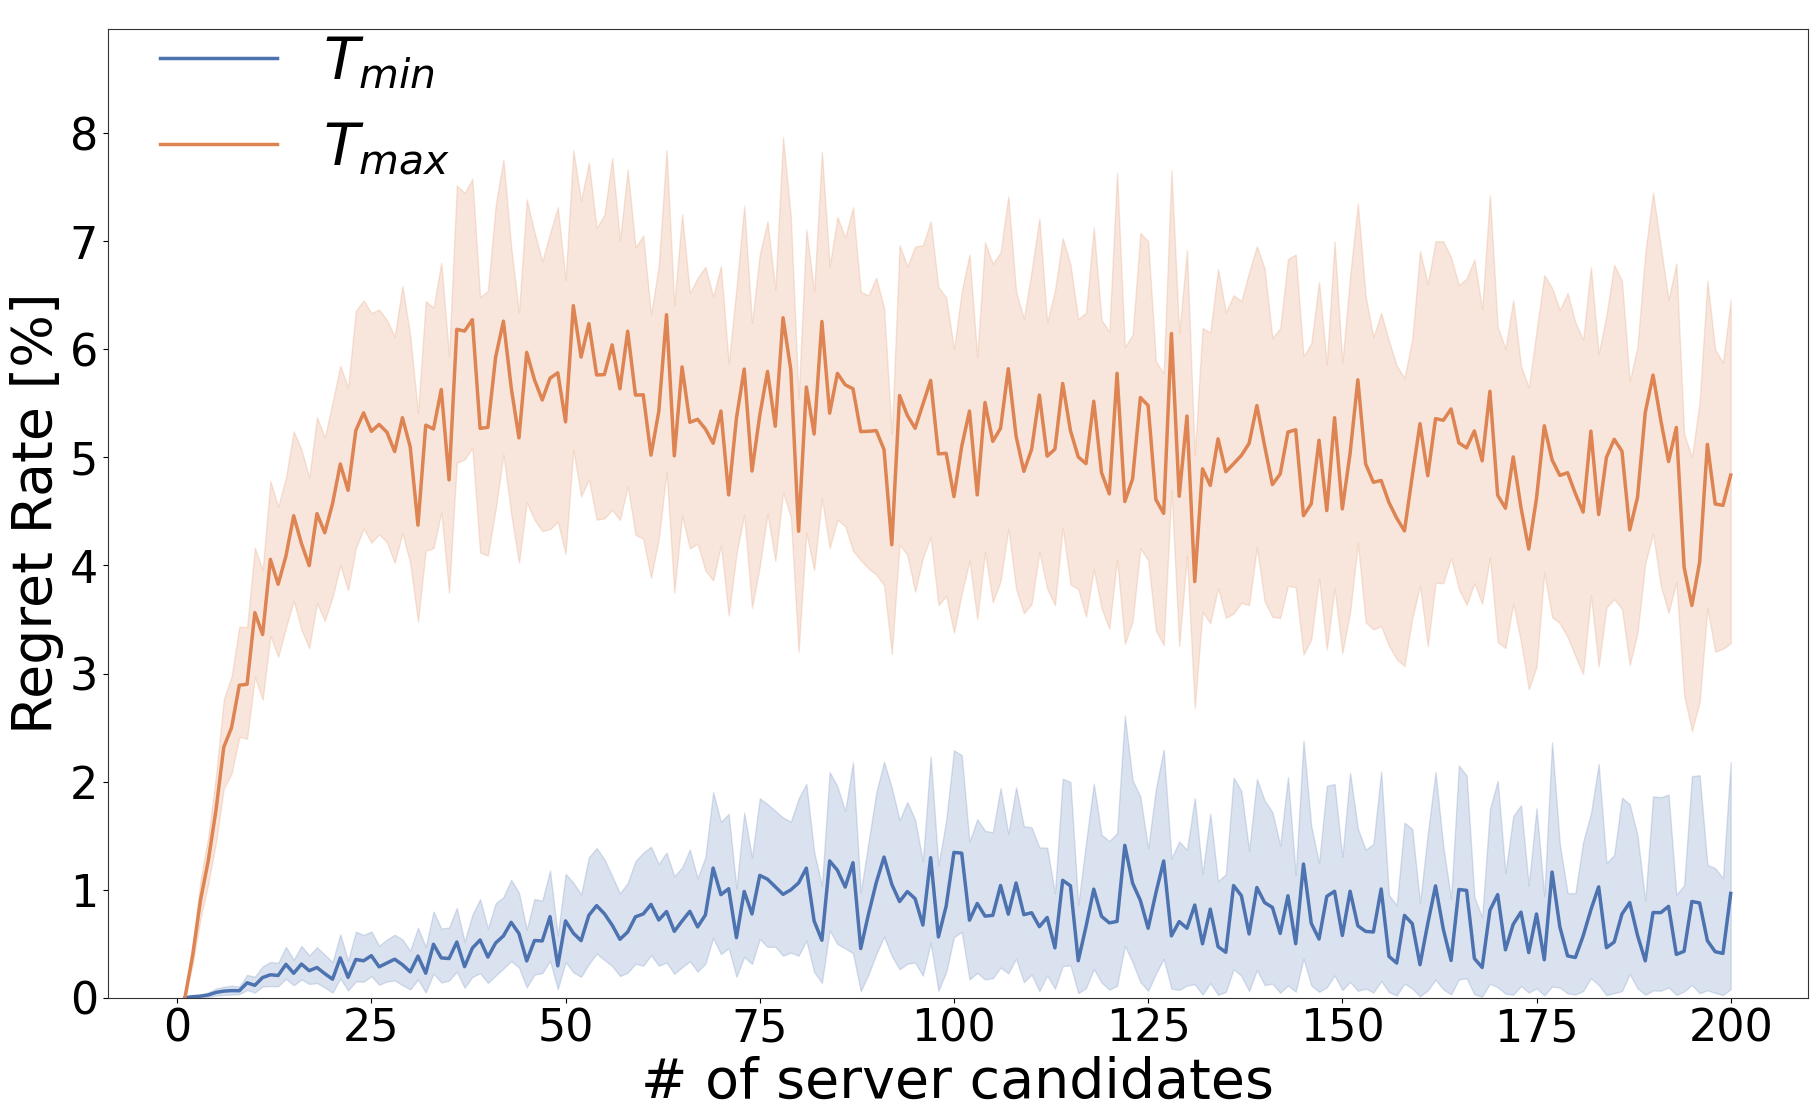

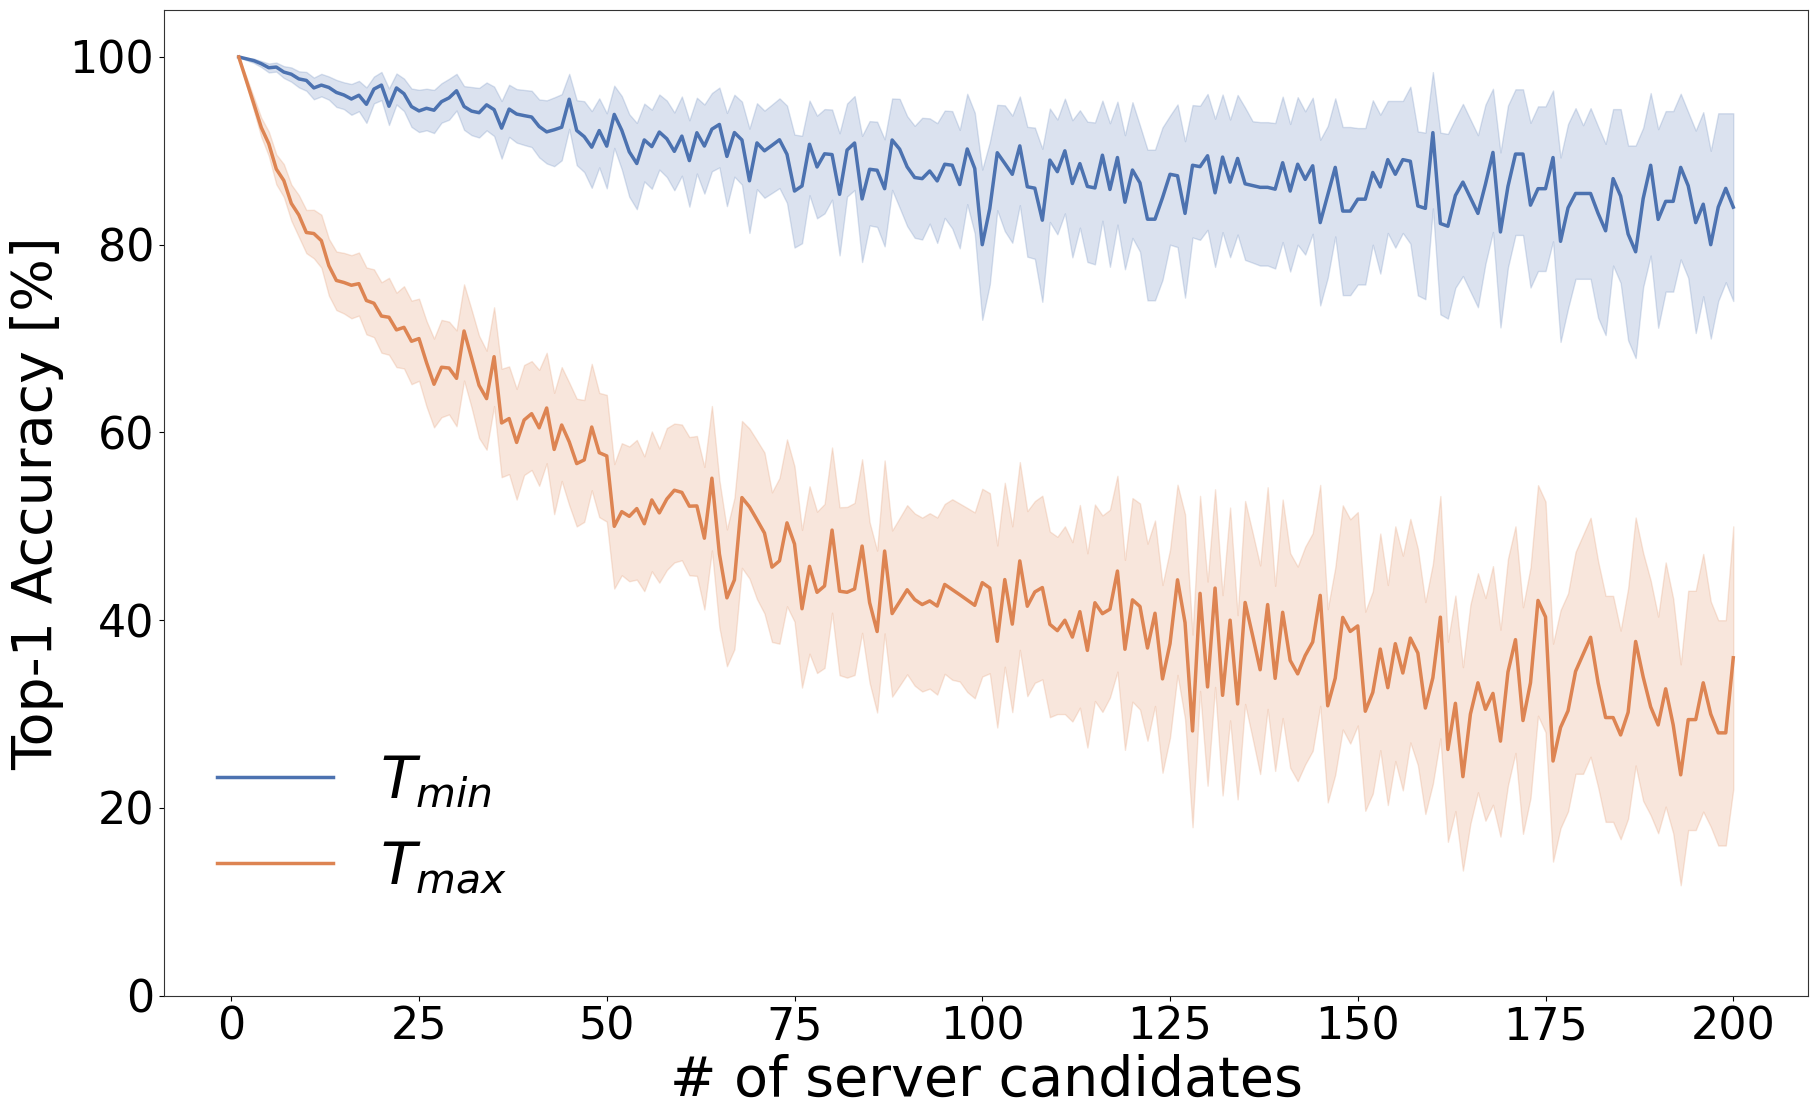

In [31]:
# === CLI factor sweep: 8 plots (4× factors × {Regret, Top-1}) ===
MAX_GROUP_SIZE = 200
from pathlib import Path
import pandas as pd, numpy as np, matplotlib.pyplot as plt

from typing import Optional

# Factors and corresponding file tag matcher (matches density_random_cli-<tag>.csv)
FACTORS = [1]
def _fmt_tag(v: float) -> str:
    s = ("%g" % v).replace('.', '_')
    s = s.replace('-', 'm')
    return s

def _find_csv(tag: str) -> Optional[Path]:
    candidates = [
        Path('data') / f'density_random_cli-{tag}.csv',
        Path('sim/src/data') / f'density_random_cli-{tag}.csv',
    ]
    for c in candidates:
        if c.exists():
            return c
    return None

# Ensure helpers exist
try:
    prepare_density_frame
except NameError:
    raise RuntimeError('prepare_density_frame is not defined in this notebook. Execute earlier cells.')

try:
    summarize_regret_rate_bootstrap, summarize_top1_bootstrap
except NameError:
    raise RuntimeError('bootstrap summarizers are not defined. Execute earlier cells.')

try:
    MAX_GROUP_SIZE
except NameError:
    MAX_GROUP_SIZE = 100

for f in FACTORS:
    tag = _fmt_tag(f)
    csv_path = _find_csv(tag)
    if not csv_path:
        print(f'[WARN] CSV for cli factor {f} (tag={tag}) not found.')
        continue
    df = prepare_density_frame(csv_path)
    rr_ci = summarize_regret_rate_bootstrap(df, MAX_GROUP_SIZE, n_boot=1500, seed=42)
    t1_ci = summarize_top1_bootstrap(df, MAX_GROUP_SIZE, n_boot=1500, seed=42)
    # (saving disabled; display only)
    # Regret plot
    fig, ax = plt.subplots(figsize=(19, 12))
    x = rr_ci['group_size']
    ax.plot(x, rr_ci['L_mean'], label=r'$T_{min}$', color='#4C72B0', linewidth=2.5)
    ax.fill_between(x, rr_ci['L_lo'], rr_ci['L_hi'], color='#4C72B0', alpha=0.2)
    ax.plot(x, rr_ci['U_mean'], label=r'$T_{max}$', color='#DD8452', linewidth=2.5)
    ax.fill_between(x, rr_ci['U_lo'], rr_ci['U_hi'], color='#DD8452', alpha=0.2)
    ax.set_xlabel('# of server candidates')
    ax.set_ylabel('Regret Rate [%]')
    # Add ~1%% headroom to avoid overlap
    ymax = float(max(rr_ci['L_hi'].max(), rr_ci['U_hi'].max()))
    ax.set_ylim(0, ymax + 1.0)
    plt.grid(False)
    ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(0, 1.05))
    plt.tight_layout()
    plt.show()
    # Top-1 plot
    fig, ax = plt.subplots(figsize=(19, 12))
    x = t1_ci['group_size']
    ax.plot(x, t1_ci['L_mean_pct'], label=r'$T_{min}$', color='#4C72B0', linewidth=2.5)
    ax.fill_between(x, t1_ci['L_lo_pct'], t1_ci['L_hi_pct'], color='#4C72B0', alpha=0.2)
    ax.plot(x, t1_ci['U_mean_pct'], label=r'$T_{max}$', color='#DD8452', linewidth=2.5)
    ax.fill_between(x, t1_ci['U_lo_pct'], t1_ci['U_hi_pct'], color='#DD8452', alpha=0.2)
    ax.set_xlabel('# of server candidates')
    ax.set_ylabel('Top-1 Accuracy [%]')
    ax.set_ylim(0, 105)
    plt.grid(False)
    ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(0, 0.3))
    plt.tight_layout()
    plt.show()
